In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:17:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   36C    P8             19W /  370W |    2230MiB /  10240MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1205_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,1,48413140,71602.0,CC(=O)NNC(=O)C1=CC=NC=C1,1
1,2,48413128,11074431.0,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],0
2,3,48413142,8247.0,CC(=O)NNC1=CC=CC=C1,1
3,4,48413158,457193.0,C[C@@H]1[C@@H](C(=O)N[C@@H](C(=O)N2CCC[C@H]2C(...,1
4,5,48413183,5284339.0,C1=C(N=C(S1)N=C(N)N)CSCCNC2=NSN=C2N,1
...,...,...,...,...,...
1097,1148,48414126,5284432.0,CC/C=C(/CC)\[N+](=O)[O-],1
1098,1149,48414669,4343483.0,[B-](F)(F)(F)F.[Na+],0
1099,1150,48414670,9352.0,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,0
1100,1151,48414671,31703.0,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 1102it [00:00, 8101.16it/s][A

Generating signatures:   0%|                                                                     | 0/9 [00:00<?, ?it/s]

1/1 [==============================] - 0s 47ms/step



Generating signatures:  11%|██████▊                                                      | 1/9 [00:00<00:03,  2.61it/s]

1/1 [==============================] - 0s 21ms/step



Generating signatures:  22%|█████████████▌                                               | 2/9 [00:00<00:02,  3.17it/s]

...

1/1 [==============================] - 0s 21ms/step



Generating signatures:  89%|██████████████████████████████████████████████████████▏      | 8/9 [00:02<00:00,  3.58it/s]

1/1 [==============================] - 0s 63ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:34<00:00, 18.98s/it]

Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1205.csv')
# 打印查看结果
print(data)

                                                 smiles      A1_0      A1_1  \
0                              CC(=O)NNC(=O)C1=CC=NC=C1 -0.098014  0.002265   
1                        CC1=CC(=O)[N-]S(=O)(=O)O1.[K+] -0.100093 -0.099089   
2                                   CC(=O)NNC1=CC=CC=C1 -0.099849  0.032688   
3     C[C@@H]1[C@@H](C(=O)N[C@@H](C(=O)N2CCC[C@H]2C(...  0.099020  0.075256   
4                   C1=C(N=C(S1)N=C(N)N)CSCCNC2=NSN=C2N  0.076254 -0.090515   
...                                                 ...       ...       ...   
1097                           CC/C=C(/CC)\[N+](=O)[O-] -0.093827 -0.093856   
1098                               [B-](F)(F)(F)F.[Na+] -0.097991 -0.054415   
1099      CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C -0.081429  0.101074   
1100  C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...  0.094905  0.095126   
1101                     C1=CC=C(C=C1)NC2=CC=C(C=C2)N=O -0.090693  0.096216   

          A1_2      A1_3      A1_4      A1_5      A

In [14]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,CC(=O)NNC(=O)C1=CC=NC=C1,-0.098010,0.002390,-0.101412,0.077286,-0.074652,0.101418,0.101440,-0.097685,0.094374,...,0.056732,-0.096194,0.120066,-0.113271,-0.020535,-0.011765,0.029151,0.084404,-0.116883,1
1,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,...,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311,0
2,CC(=O)NNC1=CC=CC=C1,-0.099847,0.032736,-0.100179,0.091849,-0.003701,0.100570,0.100114,-0.094547,0.039664,...,0.057959,-0.101668,0.020425,0.057304,0.054510,0.106825,0.008758,0.045399,0.129491,1
3,C[C@@H]1[C@@H](C(=O)N[C@@H](C(=O)N2CCC[C@H]2C(...,0.099021,0.075273,-0.096130,-0.100559,-0.065504,0.099196,0.100980,-0.078878,0.096602,...,-0.072649,-0.040036,0.002427,0.068754,0.133684,0.125872,0.021306,0.046899,0.082696,1
4,C1=C(N=C(S1)N=C(N)N)CSCCNC2=NSN=C2N,0.076265,-0.090504,0.088984,0.099890,0.099742,0.099830,0.096466,-0.099833,0.099675,...,0.050826,0.003350,-0.110016,-0.045905,0.121653,0.062609,0.093750,-0.077514,-0.002801,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,CC/C=C(/CC)\[N+](=O)[O-],-0.093829,-0.093857,0.093865,-0.080484,0.093865,0.080181,-0.093865,-0.093865,-0.092671,...,-0.039911,0.013868,0.078227,0.042474,-0.062536,-0.012488,0.001919,0.140213,-0.061796,1
1098,[B-](F)(F)(F)F.[Na+],-0.097989,-0.054378,-0.096215,0.073114,-0.087902,0.097986,0.097998,-0.097529,0.028526,...,0.039496,-0.066307,0.048998,-0.005742,-0.094280,-0.121242,0.153560,0.068190,0.045642,0
1099,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,...,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199,0
1100,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0.094904,0.095126,0.095131,-0.094880,0.095143,0.089252,0.094964,0.095148,0.062624,...,-0.104988,0.055509,0.112147,0.034040,-0.109844,0.092205,-0.108522,-0.065427,0.010976,0


In [15]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [16]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [17]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [18]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [19]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1205')

In [20]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1205/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [21]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,CC(=O)NNC(=O)C1=CC=NC=C1,-0.098010,0.002390,-0.101412,0.077286,-0.074652,0.101418,0.101440,-0.097685,0.094374,...,0.056732,-0.096194,0.120066,-0.113271,-0.020535,-0.011765,0.029151,0.084404,-0.116883,1
1,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,...,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311,0
2,CC(=O)NNC1=CC=CC=C1,-0.099847,0.032736,-0.100179,0.091849,-0.003701,0.100570,0.100114,-0.094547,0.039664,...,0.057959,-0.101668,0.020425,0.057304,0.054510,0.106825,0.008758,0.045399,0.129491,1
3,C[C@@H]1[C@@H](C(=O)N[C@@H](C(=O)N2CCC[C@H]2C(...,0.099021,0.075273,-0.096130,-0.100559,-0.065504,0.099196,0.100980,-0.078878,0.096602,...,-0.072649,-0.040036,0.002427,0.068754,0.133684,0.125872,0.021306,0.046899,0.082696,1
4,C1=C(N=C(S1)N=C(N)N)CSCCNC2=NSN=C2N,0.076265,-0.090504,0.088984,0.099890,0.099742,0.099830,0.096466,-0.099833,0.099675,...,0.050826,0.003350,-0.110016,-0.045905,0.121653,0.062609,0.093750,-0.077514,-0.002801,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,CC/C=C(/CC)\[N+](=O)[O-],-0.093829,-0.093857,0.093865,-0.080484,0.093865,0.080181,-0.093865,-0.093865,-0.092671,...,-0.039911,0.013868,0.078227,0.042474,-0.062536,-0.012488,0.001919,0.140213,-0.061796,1
1098,[B-](F)(F)(F)F.[Na+],-0.097989,-0.054378,-0.096215,0.073114,-0.087902,0.097986,0.097998,-0.097529,0.028526,...,0.039496,-0.066307,0.048998,-0.005742,-0.094280,-0.121242,0.153560,0.068190,0.045642,0
1099,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,...,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199,0
1100,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0.094904,0.095126,0.095131,-0.094880,0.095143,0.089252,0.094964,0.095148,0.062624,...,-0.104988,0.055509,0.112147,0.034040,-0.109844,0.092205,-0.108522,-0.065427,0.010976,0


In [22]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
90,C1=CC(=CC=C1C(=O)O)NN.Cl,-0.095243,0.095113,-0.089860,0.090162,-0.078394,0.097727,0.097681,-0.097715,-0.085432,...,-0.047692,-0.125958,0.102306,0.012671,-0.122872,0.105635,-0.103829,-0.060015,-0.001254,1
876,C[C@]12CC[C@H]3C(=CCC4=C3C=CC(=C4)OS(=O)(=O)[O...,-0.105289,0.060032,0.103208,-0.065566,0.107544,0.106958,0.016763,0.106885,-0.070053,...,0.001358,-0.046869,0.004160,0.140412,0.121424,-0.001037,0.015990,0.148917,0.130102,0
47,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,-0.089527,0.091871,0.091871,-0.091841,0.091871,0.091338,0.091857,0.091871,0.054305,...,-0.020955,-0.067743,-0.061504,-0.082076,-0.075281,-0.117268,-0.110041,-0.080430,0.114719,1
805,CCOP(=S)(OCC)OC1=CC=C(C=C1)[N+](=O)[O-],-0.092504,-0.092069,0.092511,-0.081556,0.092511,0.092453,-0.092511,-0.092511,-0.092406,...,0.067712,-0.110591,0.080359,0.098744,-0.062814,0.111642,0.111264,0.111169,0.098831,0
80,CCN(C#N)N=O,-0.078714,0.102840,0.107772,0.076305,0.061032,0.107599,0.108466,-0.108638,-0.105272,...,-0.056936,-0.109794,0.096924,0.071684,0.128097,-0.117925,-0.011681,0.061601,-0.106722,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,C1C(=O)NC(=O)N1N=O,-0.110008,-0.089180,-0.000089,-0.100215,0.009111,0.090875,-0.012177,0.083910,0.056800,...,-0.090310,0.060285,-0.003049,0.038965,-0.034358,-0.105832,-0.020912,0.051157,0.070911,1
626,CC1=CC(=C(C(=C1)C(C)(C)C)O)CC2=C(C(=CC(=C2)C)C...,-0.085901,-0.050759,-0.104930,0.037438,-0.100467,0.105036,0.106605,-0.105667,-0.041649,...,-0.059505,-0.131698,0.025172,0.007104,-0.030527,0.152482,0.114874,0.099728,0.062254,0
909,C1CCN(C1)N=O,-0.095697,-0.042994,-0.091763,-0.069946,-0.095419,0.094505,0.095659,-0.094808,-0.047639,...,-0.086264,0.092474,-0.006297,0.016188,-0.018397,-0.025095,-0.087066,0.113722,0.084992,1
485,CC(=O)OCC1=CC=CC=C1,-0.098348,0.014149,-0.089725,0.099293,-0.065123,0.099420,0.098993,-0.099548,-0.052124,...,0.006917,-0.042361,-0.080794,0.045165,0.166552,0.132206,0.073033,0.106791,0.061387,1


In [23]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [24]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [25]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [26]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 611
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:23:25,358:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:23:25,360:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:23:25,361:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (792, 40) 
Test shape
 (199, 40)
Before Oversampling
y_train_filtered
 1    403
0    389
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


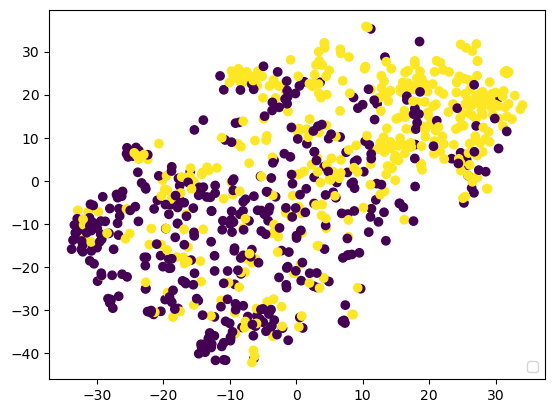

After Oversampling
Final_Ytrain
 0
1    403
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9061326658322904
Training MCC Score: 0.8122861767460848
Training F1 Score: 0.9061303132122465
Training AUC VALUE: 0.9739548086322279
Training kappa Score: 0.8122632731510635
Training Precision: 0.91
Training Recall: 0.9032258064516129
Training Sensitivity: 0.9032258064516129
Training Specificity: 0.9090909090909091
Training CCR: 0.9061326658322904
Training PPV: 0.91


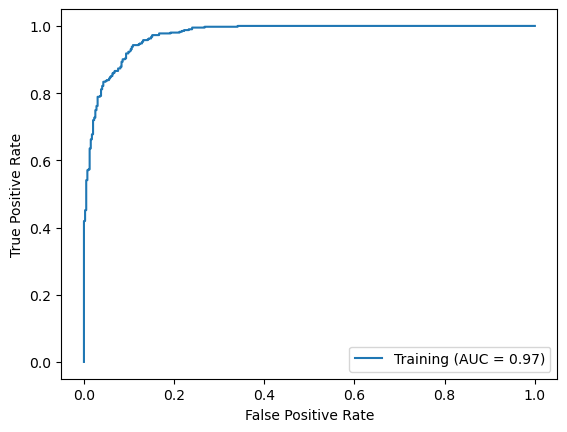

Testing Accuracy: 0.7035175879396985
Testing MCC Score: 0.4098594675840027
Testing F1 Score: 0.7034876379523702
Testing AUC VALUE: 0.7695186084142396
Testing kappa Score: 0.4081858964665558
Testing Precision: 0.7340425531914894
Testing Recall: 0.6699029126213593
Testing Sensitivity: 0.6699029126213593
Testing Specificity: 0.7395833333333334
Testing CCR: 0.7035175879396985
Testing PPV: 0.7340425531914894


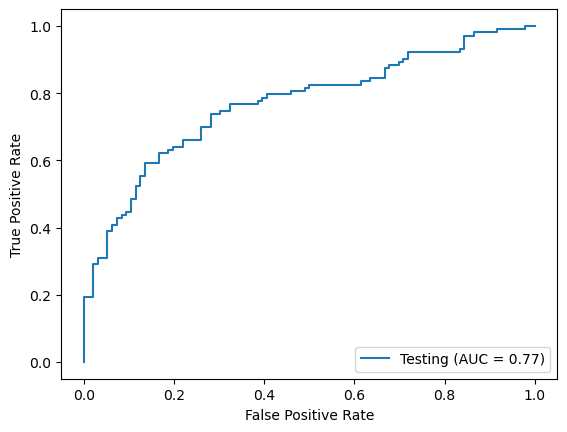

Fold # 1 Random Seed: 922
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:23:57,235:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:23:57,236:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:23:57,237:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 44
After filteration
Train shape
 (792, 44) 
Test shape
 (199, 44)
Before Oversampling
y_train_filtered
 1    404
0    388
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


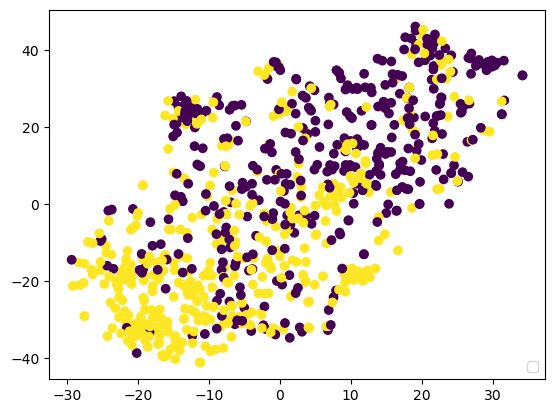

After Oversampling
Final_Ytrain
 0
1    404
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8525
Training MCC Score: 0.705094068875105
Training F1 Score: 0.8524990781192383
Training AUC VALUE: 0.9374843734373437
Training kappa Score: 0.7050147492625369
Training Precision: 0.8592964824120602
Training Recall: 0.8465346534653465
Training Sensitivity: 0.8465346534653465
Training Specificity: 0.8585858585858586
Training CCR: 0.8525
Training PPV: 0.8592964824120602


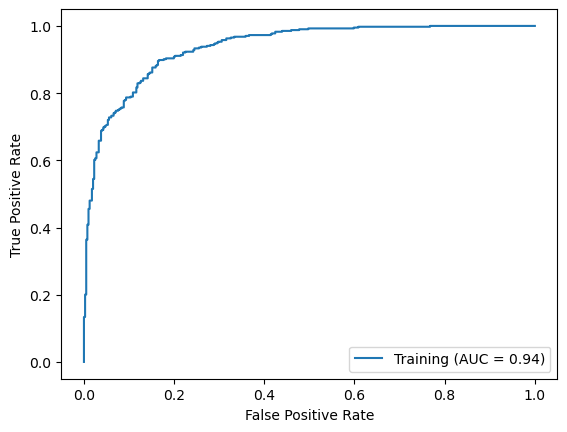

Testing Accuracy: 0.7085427135678392
Testing MCC Score: 0.4229565028474392
Testing F1 Score: 0.7079453441295547
Testing AUC VALUE: 0.7454012532848192
Testing kappa Score: 0.4187732903615671
Testing Precision: 0.75
Testing Recall: 0.6470588235294118
Testing Sensitivity: 0.6470588235294118
Testing Specificity: 0.7731958762886598
Testing CCR: 0.7085427135678392
Testing PPV: 0.75


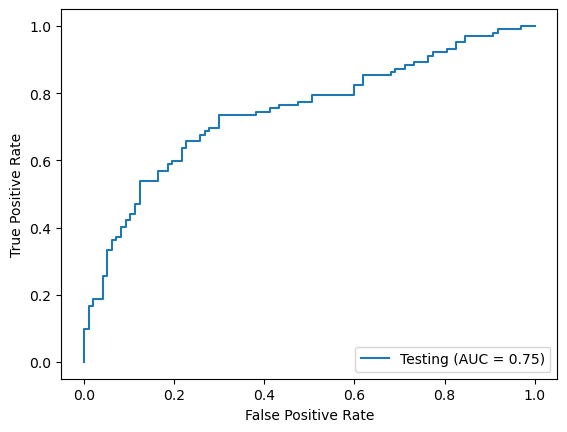

Fold # 2 Random Seed: 276
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:24:20,085:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:24:20,087:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:24:20,087:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 55
After filteration
Train shape
 (792, 55) 
Test shape
 (199, 55)
Before Oversampling
y_train_filtered
 1    406
0    386
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


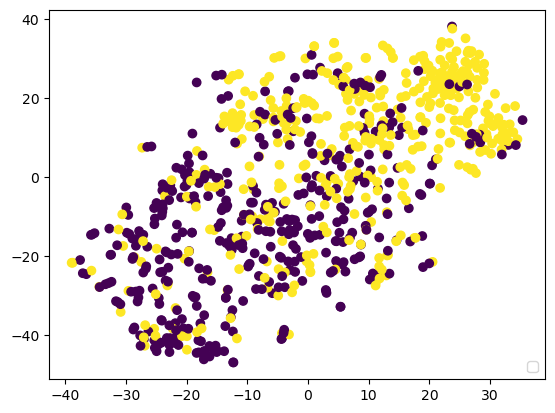

After Oversampling
Final_Ytrain
 0
1    406
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9413965087281796
Training MCC Score: 0.882861650111611
Training F1 Score: 0.9413942308439798
Training AUC VALUE: 0.9882103050206499
Training kappa Score: 0.8827930174563591
Training Precision: 0.9476309226932669
Training Recall: 0.9359605911330049
Training Sensitivity: 0.9359605911330049
Training Specificity: 0.946969696969697
Training CCR: 0.9413965087281796
Training PPV: 0.9476309226932669


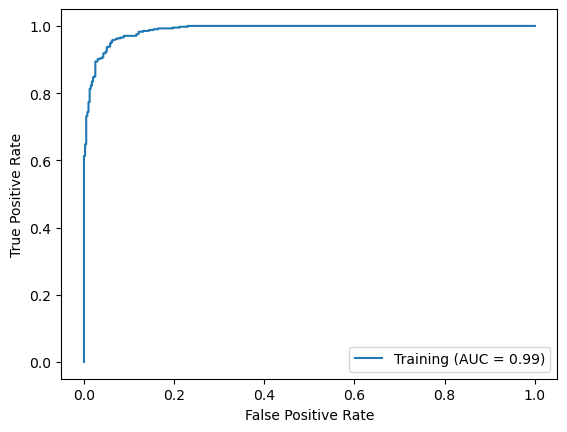

Testing Accuracy: 0.6683417085427136
Testing MCC Score: 0.33666666666666667
Testing F1 Score: 0.6683333333333333
Testing AUC VALUE: 0.7042424242424243
Testing kappa Score: 0.33666666666666667
Testing Precision: 0.67
Testing Recall: 0.67
Testing Sensitivity: 0.67
Testing Specificity: 0.6666666666666666
Testing CCR: 0.6683417085427136
Testing PPV: 0.67


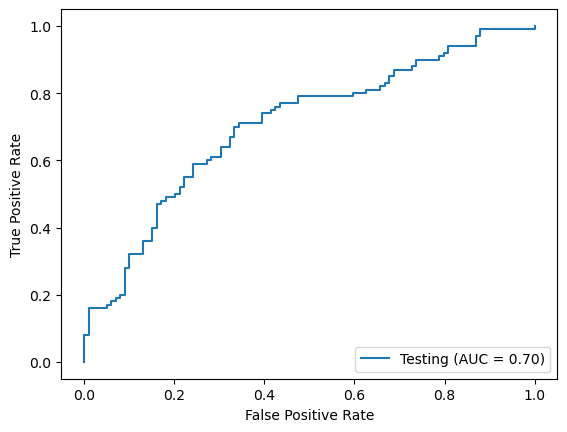

Fold # 3 Random Seed: 562
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:24:44,513:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:24:44,514:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:24:44,515:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 45
After filteration
Train shape
 (792, 45) 
Test shape
 (199, 45)
Before Oversampling
y_train_filtered
 1    411
0    381
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


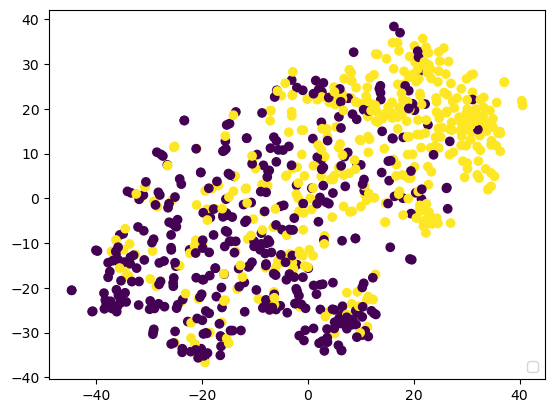

After Oversampling
Final_Ytrain
 0
1    411
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8736059479553904
Training MCC Score: 0.7474705367024528
Training F1 Score: 0.8736010957827107
Training AUC VALUE: 0.9561306495613064
Training kappa Score: 0.7472410044770345
Training Precision: 0.885286783042394
Training Recall: 0.8637469586374696
Training Sensitivity: 0.8637469586374696
Training Specificity: 0.8838383838383839
Training CCR: 0.8736059479553904
Training PPV: 0.885286783042394


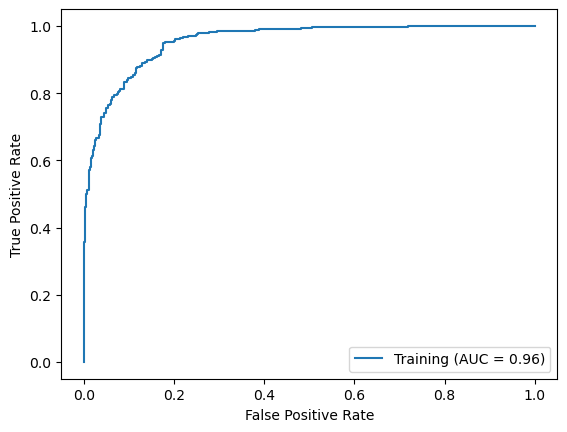

Testing Accuracy: 0.7236180904522613
Testing MCC Score: 0.4455493124017209
Testing F1 Score: 0.722609422916086
Testing AUC VALUE: 0.7644230769230768
Testing kappa Score: 0.44534536056352303
Testing Precision: 0.717391304347826
Testing Recall: 0.6947368421052632
Testing Sensitivity: 0.6947368421052632
Testing Specificity: 0.75
Testing CCR: 0.7236180904522613
Testing PPV: 0.717391304347826


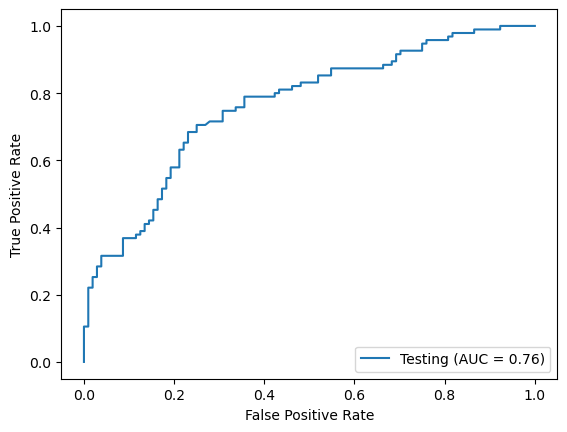

Fold # 4 Random Seed: 543
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:25:08,654:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:25:08,655:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:25:08,656:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 48
After filteration
Train shape
 (792, 48) 
Test shape
 (199, 48)
Before Oversampling
y_train_filtered
 1    409
0    383
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


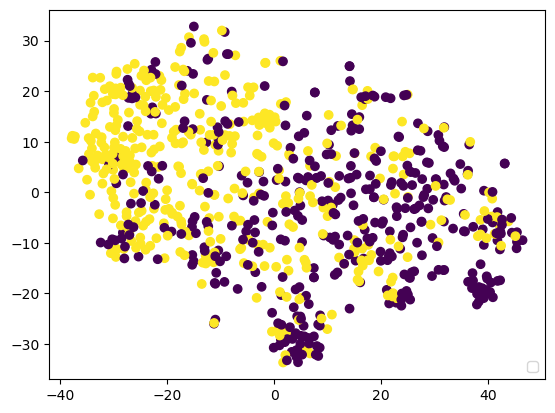

After Oversampling
Final_Ytrain
 0
1    409
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8968944099378882
Training MCC Score: 0.7937819134042617
Training F1 Score: 0.8968784967395917
Training AUC VALUE: 0.9702804326887455
Training kappa Score: 0.7937598582571681
Training Precision: 0.9014778325123153
Training Recall: 0.8948655256723717
Training Sensitivity: 0.8948655256723717
Training Specificity: 0.898989898989899
Training CCR: 0.8968944099378882
Training PPV: 0.9014778325123153


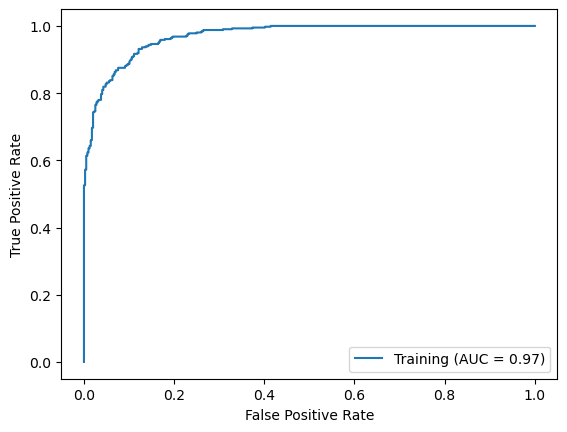

Testing Accuracy: 0.7638190954773869
Testing MCC Score: 0.5279377831711091
Testing F1 Score: 0.7637952370129051
Testing AUC VALUE: 0.8242369112593492
Testing kappa Score: 0.5276978235620866
Testing Precision: 0.75
Testing Recall: 0.7731958762886598
Testing Sensitivity: 0.7731958762886598
Testing Specificity: 0.7549019607843137
Testing CCR: 0.7638190954773869
Testing PPV: 0.75


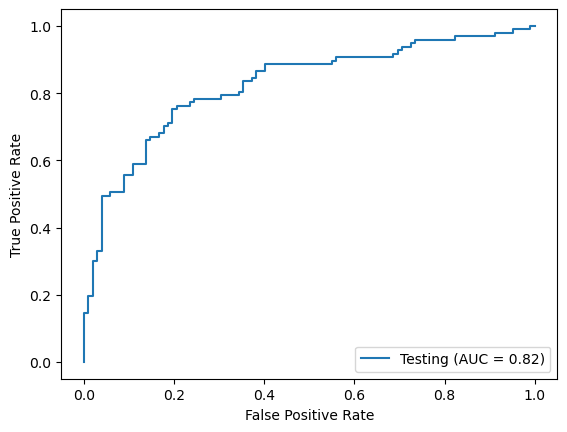

Fold # 5 Random Seed: 310
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:25:32,601:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:25:32,602:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:25:32,603:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 49
After filteration
Train shape
 (792, 49) 
Test shape
 (199, 49)
Before Oversampling
y_train_filtered
 1    400
0    392
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


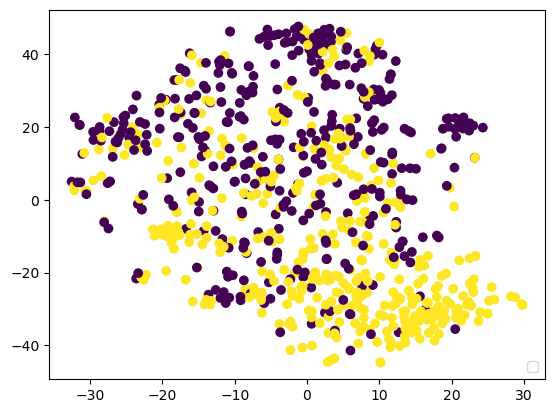

After Oversampling
Final_Ytrain
 0
1    400
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8844221105527639
Training MCC Score: 0.7693552195099533
Training F1 Score: 0.8844038666742434
Training AUC VALUE: 0.9612342171717172
Training kappa Score: 0.7688792385184438
Training Precision: 0.8989637305699482
Training Recall: 0.8675
Training Sensitivity: 0.8675
Training Specificity: 0.9015151515151515
Training CCR: 0.8844221105527639
Training PPV: 0.8989637305699482


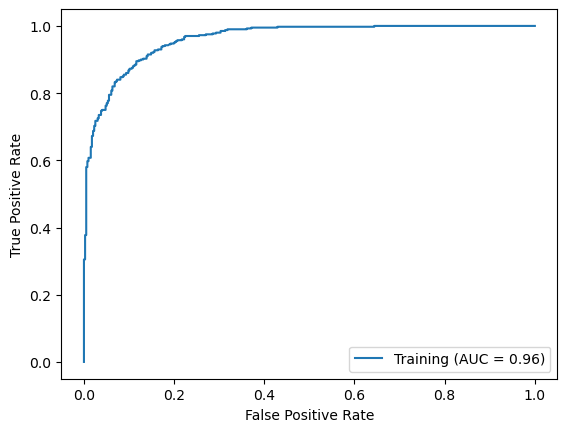

Testing Accuracy: 0.7085427135678392
Testing MCC Score: 0.4176545522917884
Testing F1 Score: 0.7081816343042071
Testing AUC VALUE: 0.738587948874011
Testing kappa Score: 0.41689400828533896
Testing Precision: 0.74
Testing Recall: 0.6981132075471698
Testing Sensitivity: 0.6981132075471698
Testing Specificity: 0.7204301075268817
Testing CCR: 0.7085427135678392
Testing PPV: 0.74


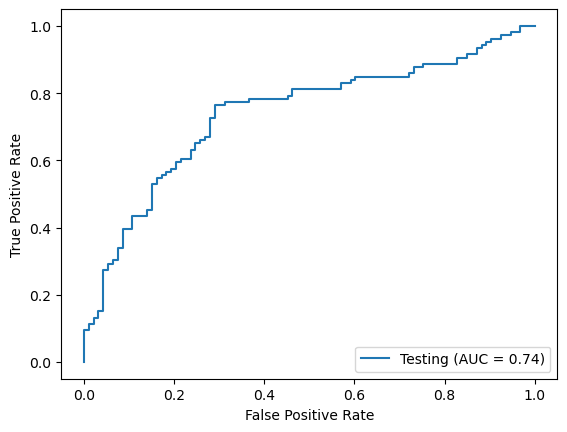

Fold # 6 Random Seed: 611
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:25:56,455:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:25:56,456:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:25:56,457:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (792, 40) 
Test shape
 (199, 40)
Before Oversampling
y_train_filtered
 1    403
0    389
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


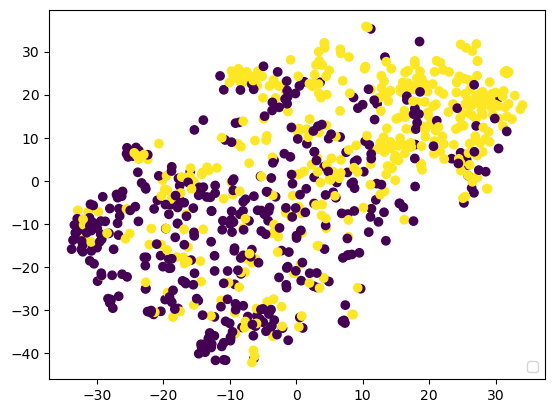

After Oversampling
Final_Ytrain
 0
1    403
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9612015018773467
Training MCC Score: 0.9224016393531529
Training F1 Score: 0.9611993138721577
Training AUC VALUE: 0.9938435220693285
Training kappa Score: 0.922398749306824
Training Precision: 0.9626865671641791
Training Recall: 0.9602977667493796
Training Sensitivity: 0.9602977667493796
Training Specificity: 0.9621212121212122
Training CCR: 0.9612015018773467
Training PPV: 0.9626865671641791


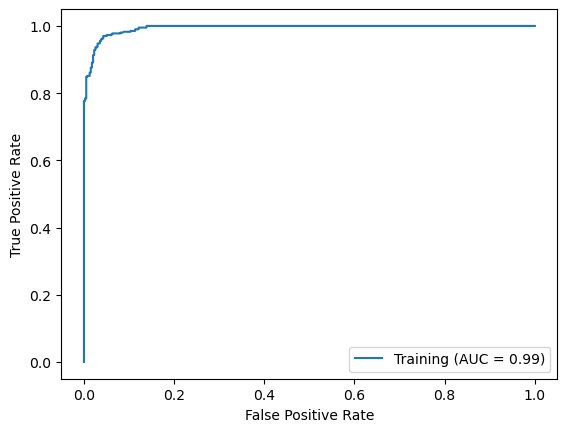

Testing Accuracy: 0.7135678391959799
Testing MCC Score: 0.4312802127254575
Testing F1 Score: 0.7134520651762031
Testing AUC VALUE: 0.7787216828478964
Testing kappa Score: 0.428650581776054
Testing Precision: 0.75
Testing Recall: 0.6699029126213593
Testing Sensitivity: 0.6699029126213593
Testing Specificity: 0.7604166666666666
Testing CCR: 0.7135678391959799
Testing PPV: 0.75


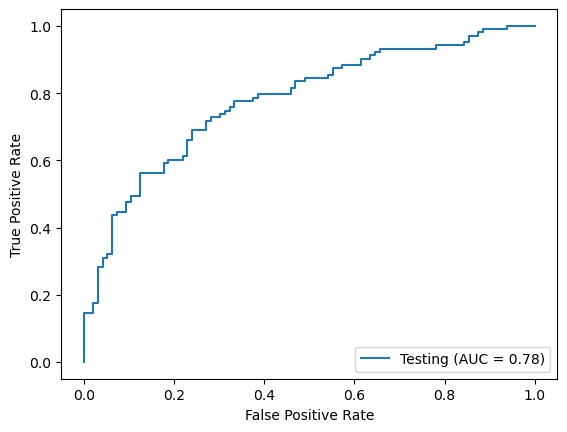

Fold # 7 Random Seed: 884
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:26:19,493:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:19,494:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:19,494:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 54
After filteration
Train shape
 (792, 54) 
Test shape
 (199, 54)
Before Oversampling
y_train_filtered
 1    405
0    387
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


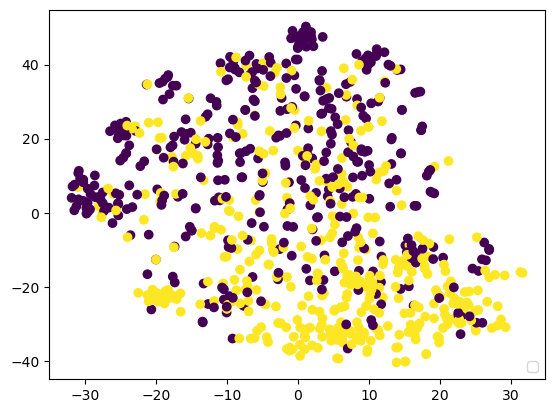

After Oversampling
Final_Ytrain
 0
1    405
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8576779026217228
Training MCC Score: 0.7155264866550944
Training F1 Score: 0.8576776807980051
Training AUC VALUE: 0.9421031300660929
Training kappa Score: 0.7153837522441652
Training Precision: 0.8664987405541562
Training Recall: 0.8493827160493828
Training Sensitivity: 0.8493827160493828
Training Specificity: 0.8661616161616161
Training CCR: 0.8576779026217228
Training PPV: 0.8664987405541562


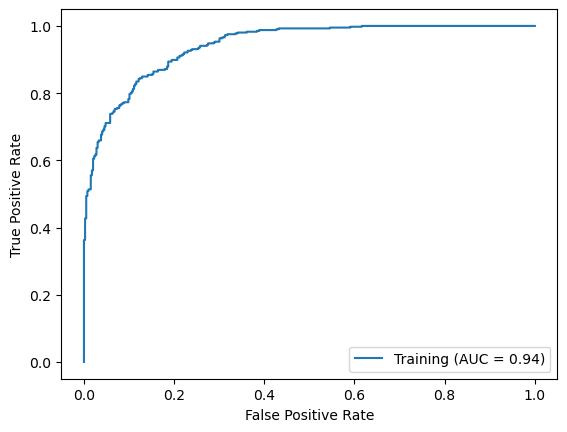

Testing Accuracy: 0.7185929648241206
Testing MCC Score: 0.43775263626421
Testing F1 Score: 0.7185858585858587
Testing AUC VALUE: 0.7752071125479894
Testing kappa Score: 0.4373990306946688
Testing Precision: 0.7319587628865979
Testing Recall: 0.7029702970297029
Testing Sensitivity: 0.7029702970297029
Testing Specificity: 0.7346938775510204
Testing CCR: 0.7185929648241206
Testing PPV: 0.7319587628865979


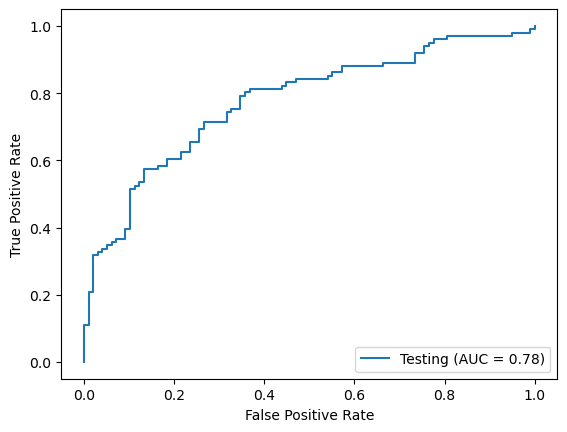

Fold # 8 Random Seed: 97
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:26:43,437:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:43,438:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:43,439:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 42
After filteration
Train shape
 (792, 42) 
Test shape
 (199, 42)
Before Oversampling
y_train_filtered
 0    397
1    395
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


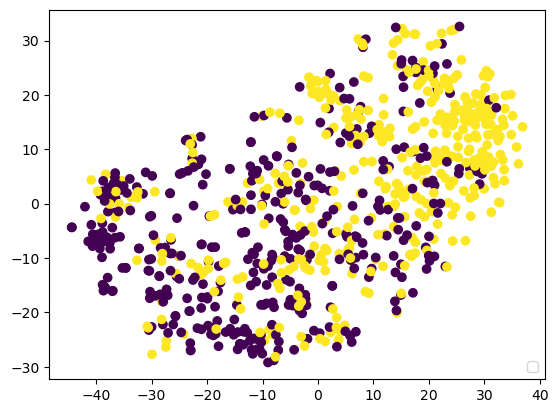

After Oversampling
Final_Ytrain
 0
0    397
1    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8663303909205549
Training MCC Score: 0.7334012664183129
Training F1 Score: 0.8662536118430264
Training AUC VALUE: 0.9562088135765717
Training kappa Score: 0.7326450513030922
Training Precision: 0.8835978835978836
Training Recall: 0.8434343434343434
Training Sensitivity: 0.8434343434343434
Training Specificity: 0.889168765743073
Training CCR: 0.8663303909205549
Training PPV: 0.8835978835978836


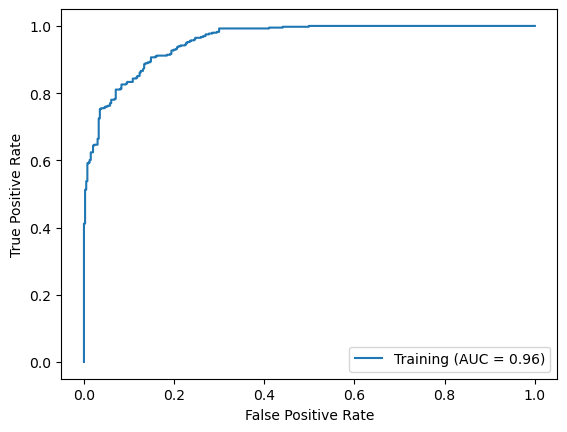

Testing Accuracy: 0.6582914572864321
Testing MCC Score: 0.3243130867006356
Testing F1 Score: 0.6578681229773463
Testing AUC VALUE: 0.7490786240786241
Testing kappa Score: 0.320136655948553
Testing Precision: 0.7263157894736842
Testing Recall: 0.6216216216216216
Testing Sensitivity: 0.6216216216216216
Testing Specificity: 0.7045454545454546
Testing CCR: 0.6582914572864321
Testing PPV: 0.7263157894736842


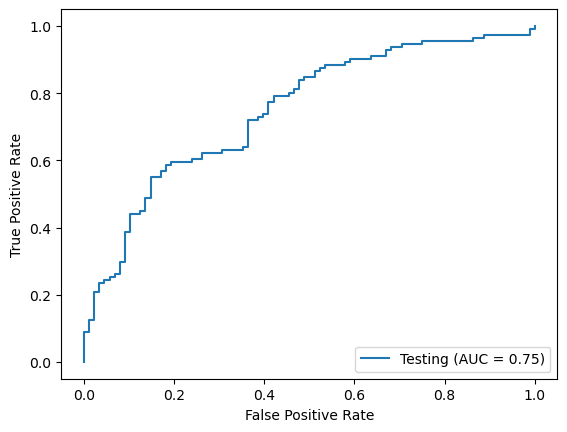

Fold # 9 Random Seed: 322
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:27:08,866:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:27:08,867:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:27:08,868:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 46
After filteration
Train shape
 (792, 46) 
Test shape
 (199, 46)
Before Oversampling
y_train_filtered
 1    410
0    382
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


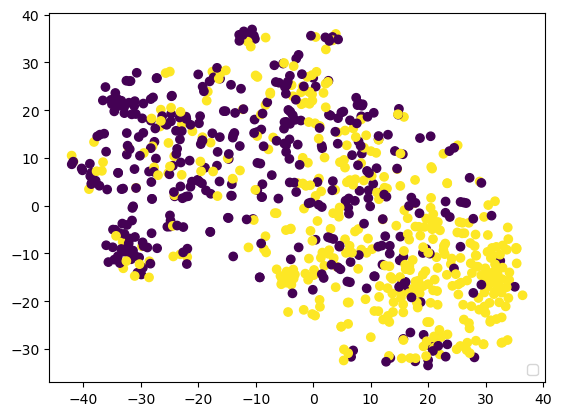

After Oversampling
Final_Ytrain
 0
1    410
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8052109181141439
Training MCC Score: 0.6108402908203018
Training F1 Score: 0.8052106182702594
Training AUC VALUE: 0.9040188470066519
Training kappa Score: 0.6105225575712061
Training Precision: 0.818639798488665
Training Recall: 0.7926829268292683
Training Sensitivity: 0.7926829268292683
Training Specificity: 0.8181818181818182
Training CCR: 0.8052109181141439
Training PPV: 0.818639798488665


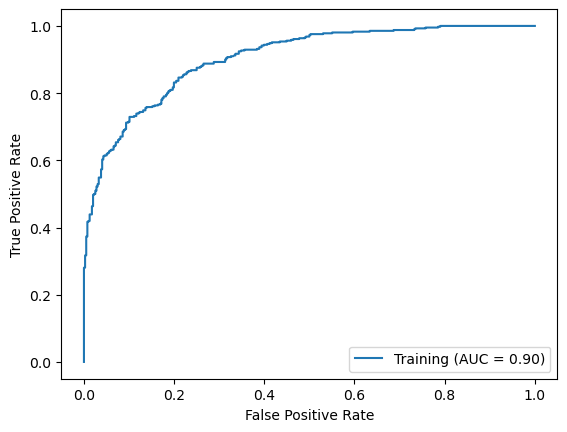

Testing Accuracy: 0.7035175879396985
Testing MCC Score: 0.40576369673636575
Testing F1 Score: 0.7024355627645285
Testing AUC VALUE: 0.7700242718446602
Testing kappa Score: 0.40524796109619576
Testing Precision: 0.7032967032967034
Testing Recall: 0.6666666666666666
Testing Sensitivity: 0.6666666666666666
Testing Specificity: 0.7378640776699029
Testing CCR: 0.7035175879396985
Testing PPV: 0.7032967032967034


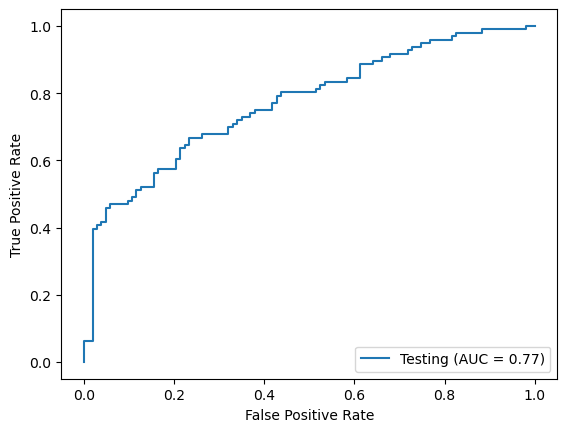

Fold # 10 Random Seed: 729
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:27:31,470:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:27:31,471:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:27:31,472:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 45
After filteration
Train shape
 (792, 45) 
Test shape
 (199, 45)
Before Oversampling
y_train_filtered
 0    397
1    395
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


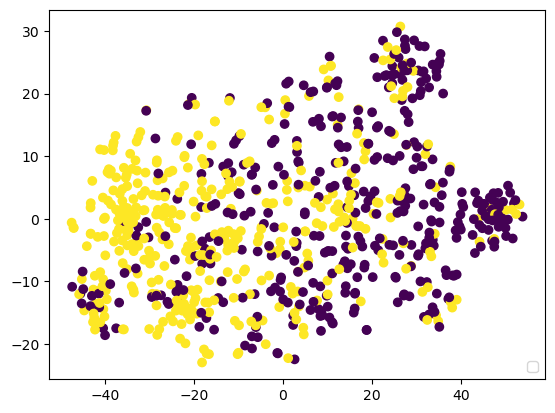

After Oversampling
Final_Ytrain
 0
0    397
1    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9634300126103404
Training MCC Score: 0.9269324520402477
Training F1 Score: 0.9634279189520574
Training AUC VALUE: 0.9938745133959239
Training kappa Score: 0.9268587458137072
Training Precision: 0.969309462915601
Training Recall: 0.9570707070707071
Training Sensitivity: 0.9570707070707071
Training Specificity: 0.9697732997481109
Training CCR: 0.9634300126103404
Training PPV: 0.969309462915601


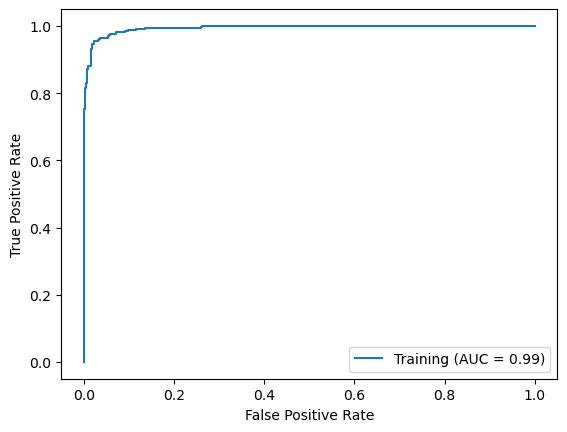

Testing Accuracy: 0.7286432160804021
Testing MCC Score: 0.45866963700276264
Testing F1 Score: 0.7274802191113816
Testing AUC VALUE: 0.7821457821457822
Testing kappa Score: 0.4563391682687443
Testing Precision: 0.7821782178217822
Testing Recall: 0.7117117117117117
Testing Sensitivity: 0.7117117117117117
Testing Specificity: 0.75
Testing CCR: 0.7286432160804021
Testing PPV: 0.7821782178217822


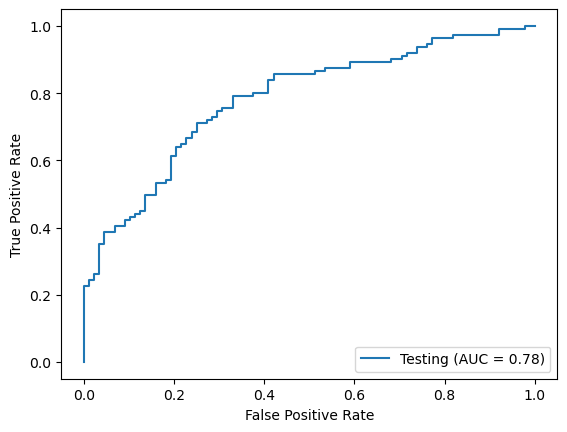

Fold # 11 Random Seed: 327
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:27:54,782:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:27:54,783:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:27:54,783:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

# of Features selected: 39
After filteration
Train shape
 (792, 39) 
Test shape
 (199, 39)
Before Oversampling
y_train_filtered
 1    401
0    391
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


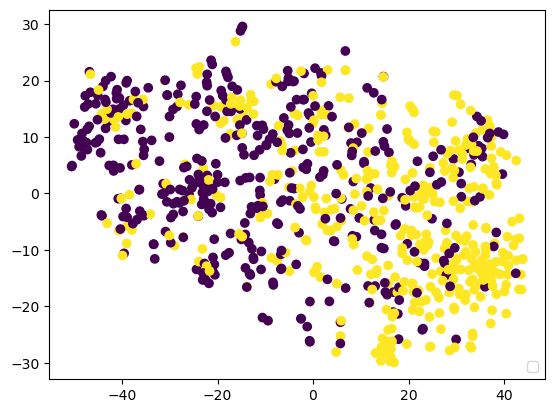

After Oversampling
Final_Ytrain
 0
1    401
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8080301129234629
Training MCC Score: 0.6167090136726344
Training F1 Score: 0.8079865840504515
Training AUC VALUE: 0.8929727449054131
Training kappa Score: 0.6161478482861522
Training Precision: 0.8229166666666666
Training Recall: 0.7880299251870324
Training Sensitivity: 0.7880299251870324
Training Specificity: 0.8282828282828283
Training CCR: 0.8080301129234629
Training PPV: 0.8229166666666666


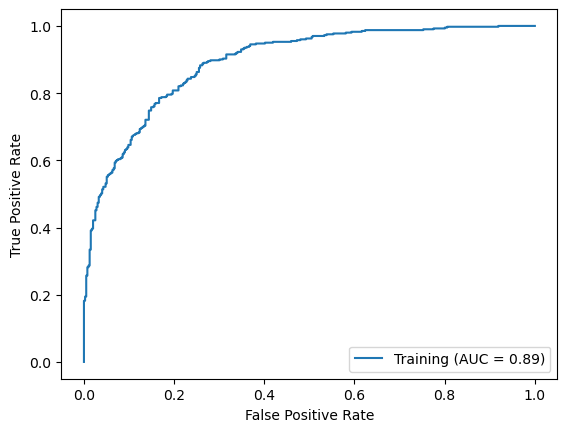

Testing Accuracy: 0.7386934673366834
Testing MCC Score: 0.4796603415092395
Testing F1 Score: 0.7386340674883816
Testing AUC VALUE: 0.8064842958459979
Testing kappa Score: 0.4781117611458544
Testing Precision: 0.7731958762886598
Testing Recall: 0.7142857142857143
Testing Sensitivity: 0.7142857142857143
Testing Specificity: 0.7659574468085106
Testing CCR: 0.7386934673366834
Testing PPV: 0.7731958762886598


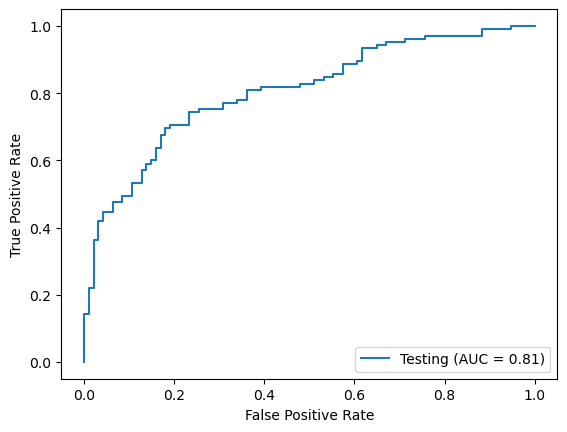

Fold # 12 Random Seed: 146
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:28:16,824:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:28:16,825:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:28:16,826:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 41
After filteration
Train shape
 (792, 41) 
Test shape
 (199, 41)
Before Oversampling
y_train_filtered
 1    410
0    382
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


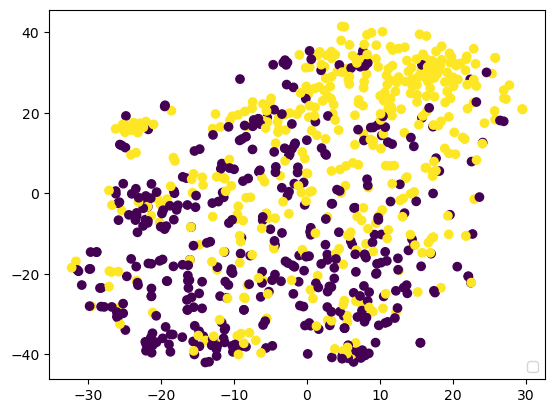

After Oversampling
Final_Ytrain
 0
1    410
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9379652605459057
Training MCC Score: 0.876216289439691
Training F1 Score: 0.9379637326436994
Training AUC VALUE: 0.9860187238236019
Training kappa Score: 0.8759465615957643
Training Precision: 0.95
Training Recall: 0.926829268292683
Training Sensitivity: 0.926829268292683
Training Specificity: 0.9494949494949495
Training CCR: 0.9379652605459057
Training PPV: 0.95


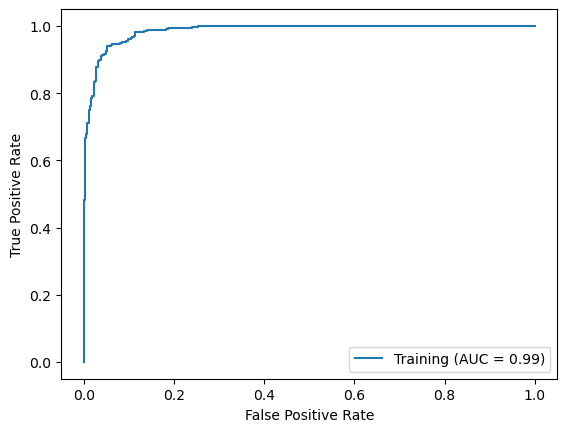

Testing Accuracy: 0.7135678391959799
Testing MCC Score: 0.42748208620246336
Testing F1 Score: 0.7106451366036581
Testing AUC VALUE: 0.7718446601941747
Testing kappa Score: 0.42377444754889515
Testing Precision: 0.7349397590361446
Testing Recall: 0.6354166666666666
Testing Sensitivity: 0.6354166666666666
Testing Specificity: 0.7864077669902912
Testing CCR: 0.7135678391959799
Testing PPV: 0.7349397590361446


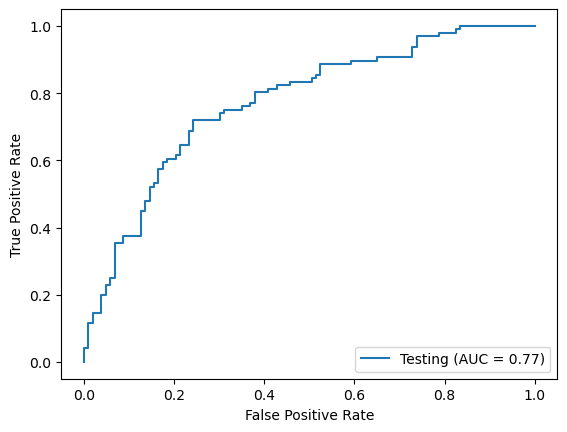

Fold # 13 Random Seed: 523
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:28:39,532:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:28:39,533:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:28:39,534:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 45
After filteration
Train shape
 (792, 45) 
Test shape
 (199, 45)
Before Oversampling
y_train_filtered
 1    411
0    381
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


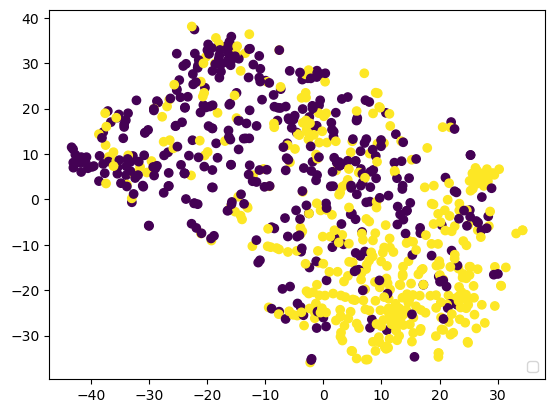

After Oversampling
Final_Ytrain
 0
1    411
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8475836431226765
Training MCC Score: 0.6965156280499873
Training F1 Score: 0.8475686632830917
Training AUC VALUE: 0.9386504952198383
Training kappa Score: 0.6953847853506292
Training Precision: 0.8711340206185567
Training Recall: 0.8223844282238443
Training Sensitivity: 0.8223844282238443
Training Specificity: 0.8737373737373737
Training CCR: 0.8475836431226765
Training PPV: 0.8711340206185567


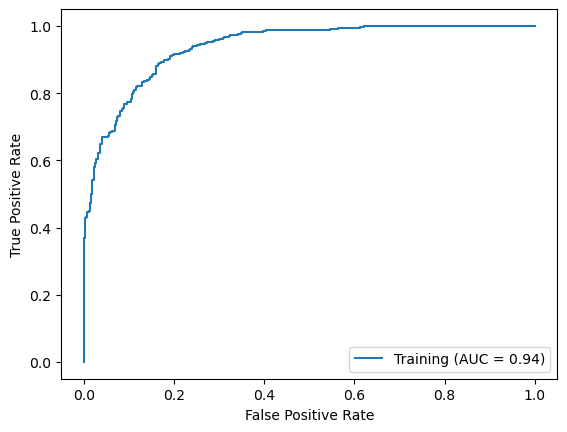

Testing Accuracy: 0.7185929648241206
Testing MCC Score: 0.4374117503927746
Testing F1 Score: 0.7184152011319993
Testing AUC VALUE: 0.7952429149797571
Testing kappa Score: 0.43705799151343705
Testing Precision: 0.696969696969697
Testing Recall: 0.7263157894736842
Testing Sensitivity: 0.7263157894736842
Testing Specificity: 0.7115384615384616
Testing CCR: 0.7185929648241206
Testing PPV: 0.696969696969697


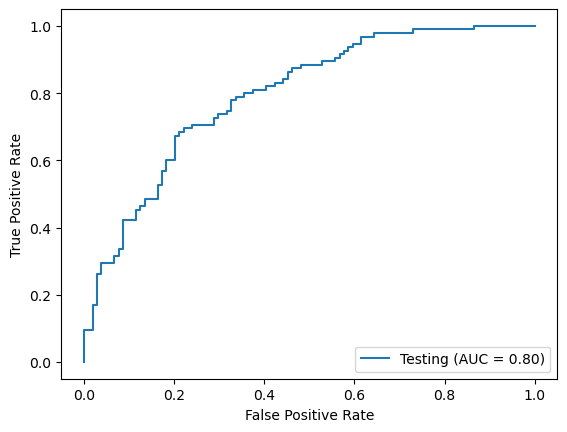

Fold # 14 Random Seed: 534
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:29:02,204:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:29:02,205:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:29:02,206:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 41
After filteration
Train shape
 (792, 41) 
Test shape
 (199, 41)
Before Oversampling
y_train_filtered
 1    398
0    394
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


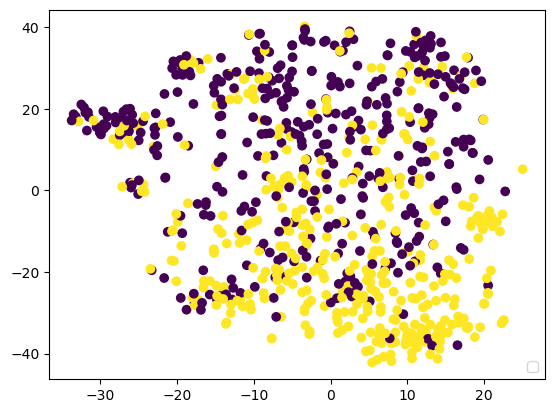

After Oversampling
Final_Ytrain
 0
1    398
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8438287153652393
Training MCC Score: 0.6882462247180479
Training F1 Score: 0.8437801472454938
Training AUC VALUE: 0.9403012537434648
Training kappa Score: 0.687687154240471
Training Precision: 0.8586387434554974
Training Recall: 0.8241206030150754
Training Sensitivity: 0.8241206030150754
Training Specificity: 0.8636363636363636
Training CCR: 0.8438287153652393
Training PPV: 0.8586387434554974


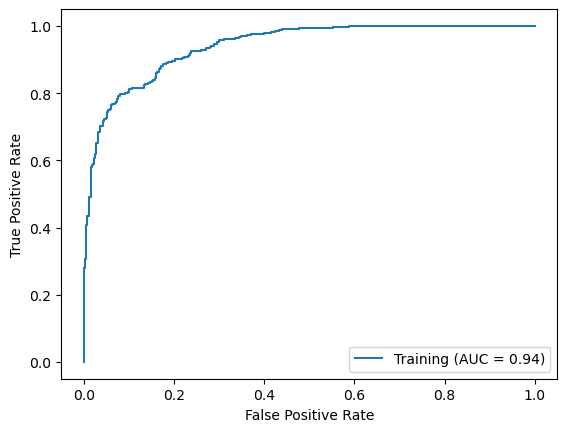

Testing Accuracy: 0.7537688442211056
Testing MCC Score: 0.5138032904292916
Testing F1 Score: 0.7536693191865604
Testing AUC VALUE: 0.8094220594220595
Testing kappa Score: 0.5094330130301353
Testing Precision: 0.8105263157894737
Testing Recall: 0.7129629629629629
Testing Sensitivity: 0.7129629629629629
Testing Specificity: 0.8021978021978022
Testing CCR: 0.7537688442211056
Testing PPV: 0.8105263157894737


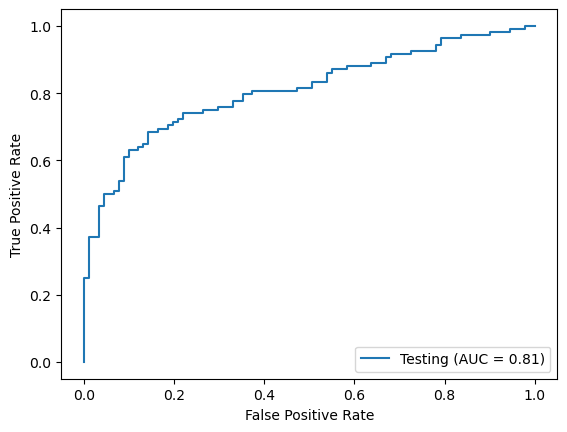

Fold # 15 Random Seed: 994
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:29:24,835:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:29:24,836:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:29:24,837:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

# of Features selected: 45
After filteration
Train shape
 (792, 45) 
Test shape
 (199, 45)
Before Oversampling
y_train_filtered
 1    414
0    378
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


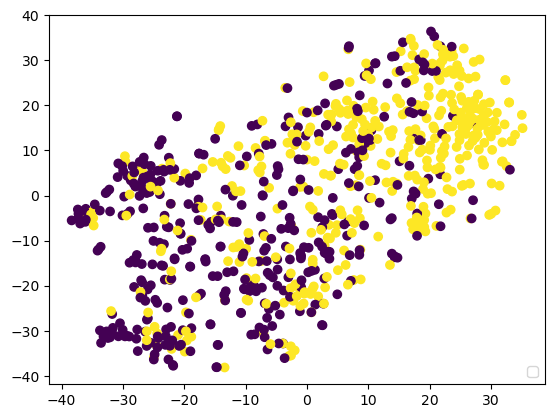

After Oversampling
Final_Ytrain
 0
1    414
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8901234567901235
Training MCC Score: 0.7804396385217016
Training F1 Score: 0.8901098901098902
Training AUC VALUE: 0.9645763187429854
Training kappa Score: 0.7802469135802469
Training Precision: 0.9012345679012346
Training Recall: 0.8816425120772947
Training Sensitivity: 0.8816425120772947
Training Specificity: 0.898989898989899
Training CCR: 0.8901234567901235
Training PPV: 0.9012345679012346


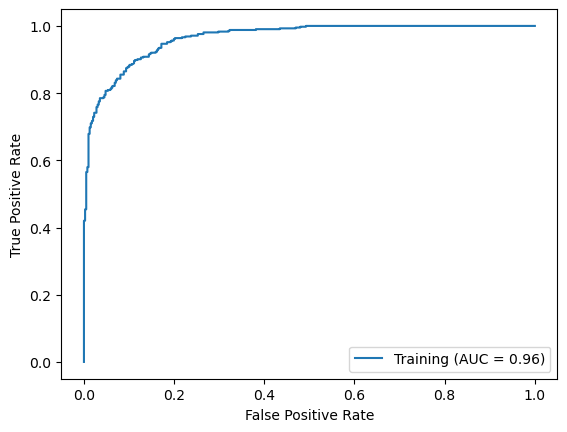

Testing Accuracy: 0.6733668341708543
Testing MCC Score: 0.35059888503345654
Testing F1 Score: 0.6732348111658457
Testing AUC VALUE: 0.7660503860219423
Testing kappa Score: 0.34846118974462303
Testing Precision: 0.6310679611650486
Testing Recall: 0.7065217391304348
Testing Sensitivity: 0.7065217391304348
Testing Specificity: 0.6448598130841121
Testing CCR: 0.6733668341708543
Testing PPV: 0.6310679611650486


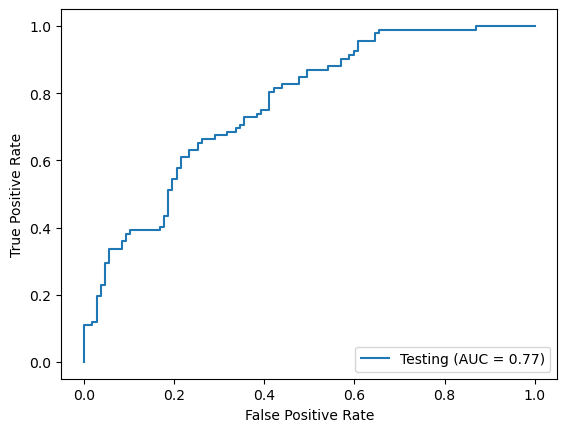

Fold # 16 Random Seed: 196
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:29:47,950:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:29:47,952:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:29:47,953:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 49
After filteration
Train shape
 (792, 49) 
Test shape
 (199, 49)
Before Oversampling
y_train_filtered
 1    416
0    376
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


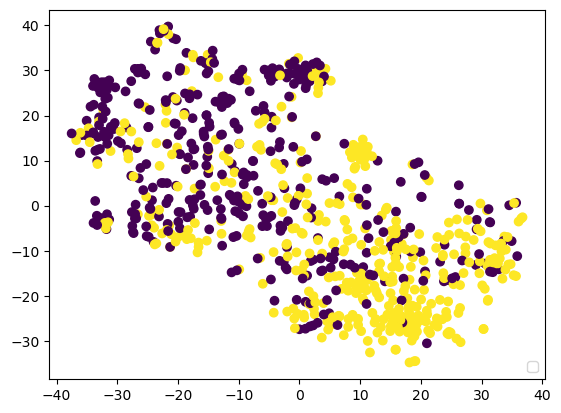

After Oversampling
Final_Ytrain
 0
1    416
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8793103448275862
Training MCC Score: 0.7584741647241647
Training F1 Score: 0.8792370823620823
Training AUC VALUE: 0.9570555312742814
Training kappa Score: 0.7584741647241647
Training Precision: 0.8822115384615384
Training Recall: 0.8822115384615384
Training Sensitivity: 0.8822115384615384
Training Specificity: 0.8762626262626263
Training CCR: 0.8793103448275862
Training PPV: 0.8822115384615384


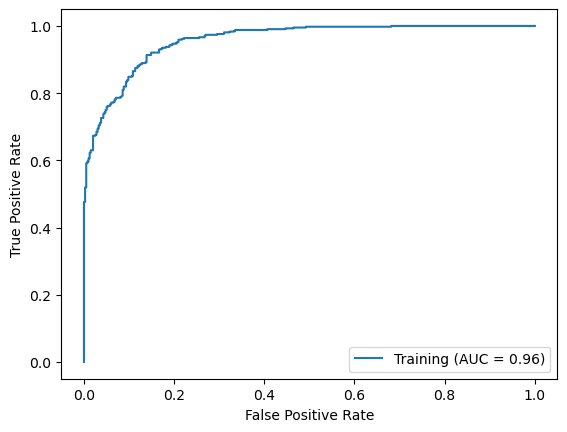

Testing Accuracy: 0.6934673366834171
Testing MCC Score: 0.38071448392054513
Testing F1 Score: 0.6903395321547919
Testing AUC VALUE: 0.746585117227319
Testing kappa Score: 0.3806948625070149
Testing Precision: 0.6629213483146067
Testing Recall: 0.6555555555555556
Testing Sensitivity: 0.6555555555555556
Testing Specificity: 0.7247706422018348
Testing CCR: 0.6934673366834171
Testing PPV: 0.6629213483146067


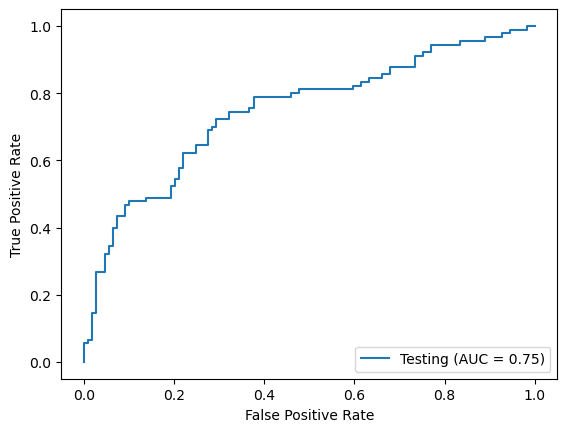

Fold # 17 Random Seed: 385
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:30:11,535:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:30:11,537:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:30:11,537:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 46
After filteration
Train shape
 (792, 46) 
Test shape
 (199, 46)
Before Oversampling
y_train_filtered
 1    408
0    384
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


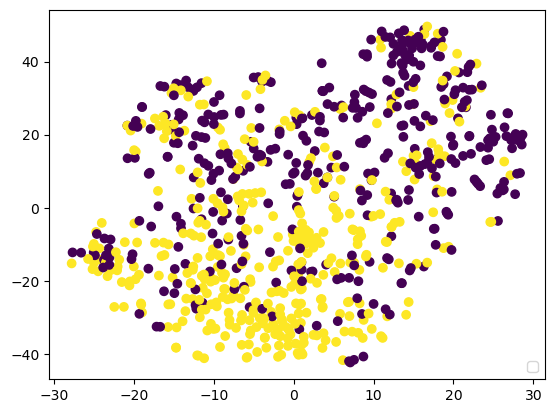

After Oversampling
Final_Ytrain
 0
1    408
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8768656716417911
Training MCC Score: 0.7537805107160798
Training F1 Score: 0.876856337034533
Training AUC VALUE: 0.9582002624282037
Training kappa Score: 0.7537221995321725
Training Precision: 0.8833746898263027
Training Recall: 0.8725490196078431
Training Sensitivity: 0.8725490196078431
Training Specificity: 0.8813131313131313
Training CCR: 0.8768656716417911
Training PPV: 0.8833746898263027


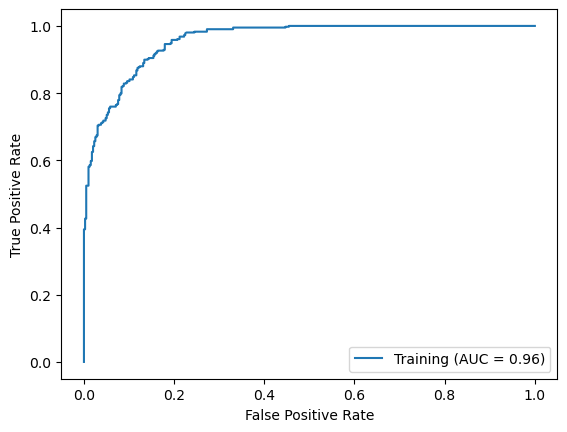

Testing Accuracy: 0.7336683417085427
Testing MCC Score: 0.4671584573983017
Testing F1 Score: 0.7335606921813818
Testing AUC VALUE: 0.7645989088704789
Testing kappa Score: 0.4671348456525034
Testing Precision: 0.7319587628865979
Testing Recall: 0.7244897959183674
Testing Sensitivity: 0.7244897959183674
Testing Specificity: 0.7425742574257426
Testing CCR: 0.7336683417085427
Testing PPV: 0.7319587628865979


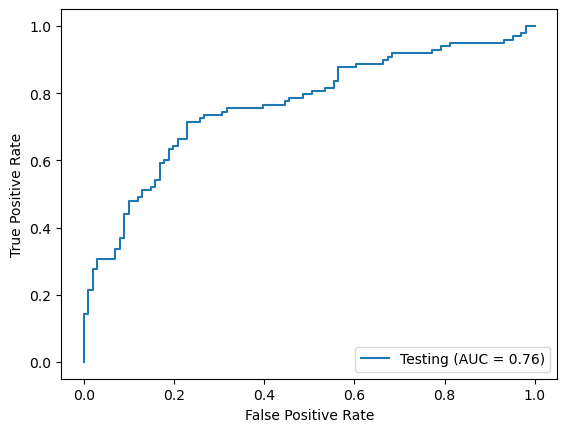

Fold # 18 Random Seed: 389
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:30:35,043:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:30:35,045:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:30:35,045:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

# of Features selected: 48
After filteration
Train shape
 (792, 48) 
Test shape
 (199, 48)
Before Oversampling
y_train_filtered
 1    407
0    385
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


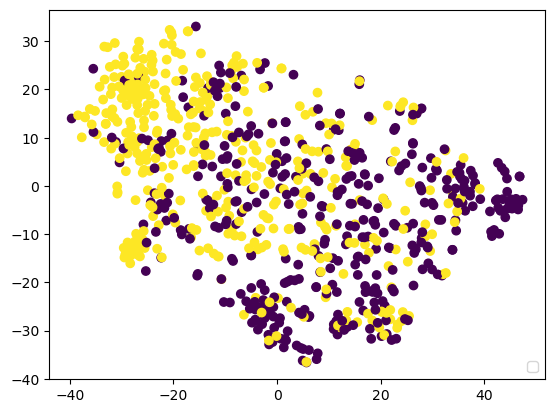

After Oversampling
Final_Ytrain
 0
1    407
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9576587795765878
Training MCC Score: 0.9153016653016653
Training F1 Score: 0.9576508326508327
Training AUC VALUE: 0.9930757203484477
Training kappa Score: 0.9153016653016653
Training Precision: 0.9582309582309583
Training Recall: 0.9582309582309583
Training Sensitivity: 0.9582309582309583
Training Specificity: 0.9570707070707071
Training CCR: 0.9576587795765878
Training PPV: 0.9582309582309583


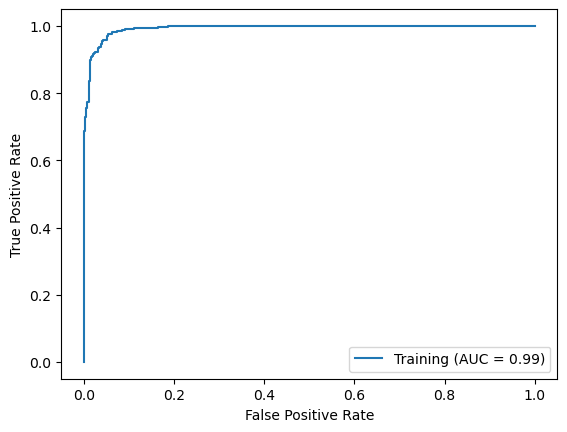

Testing Accuracy: 0.7185929648241206
Testing MCC Score: 0.43763905358702065
Testing F1 Score: 0.7185289957567185
Testing AUC VALUE: 0.7772727272727273
Testing kappa Score: 0.4372853968895173
Testing Precision: 0.7087378640776699
Testing Recall: 0.7373737373737373
Testing Sensitivity: 0.7373737373737373
Testing Specificity: 0.7
Testing CCR: 0.7185929648241206
Testing PPV: 0.7087378640776699


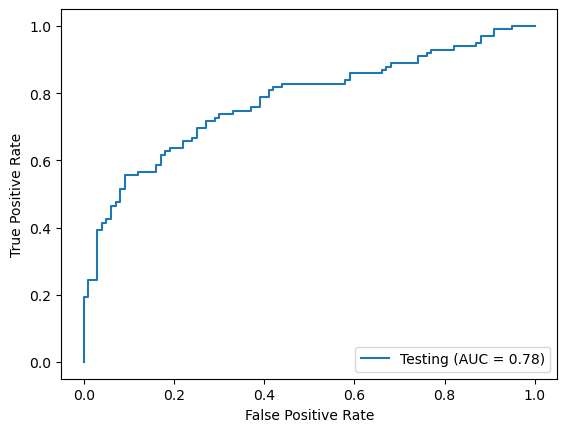

Fold # 19 Random Seed: 547
Before filteration
Train shape
 (792, 3200) 
Test shape
 (199, 3200)


2024-11-04 22:30:59,309:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:30:59,310:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:30:59,311:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 49
After filteration
Train shape
 (792, 49) 
Test shape
 (199, 49)
Before Oversampling
y_train_filtered
 1    399
0    393
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


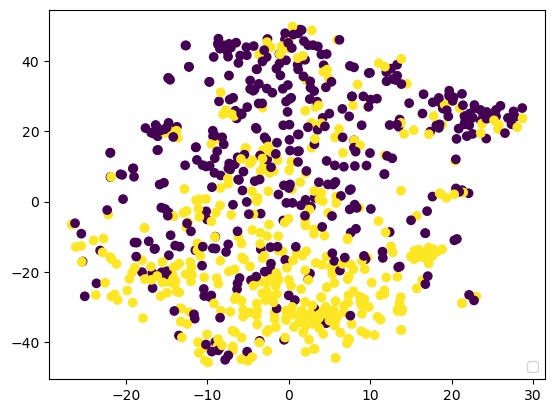

After Oversampling
Final_Ytrain
 0
1    399
0    396
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9572327044025157
Training MCC Score: 0.9144741426993088
Training F1 Score: 0.957231012658228
Training AUC VALUE: 0.9930697957013747
Training kappa Score: 0.9144625666926158
Training Precision: 0.9551122194513716
Training Recall: 0.9598997493734336
Training Sensitivity: 0.9598997493734336
Training Specificity: 0.9545454545454546
Training CCR: 0.9572327044025157
Training PPV: 0.9551122194513716


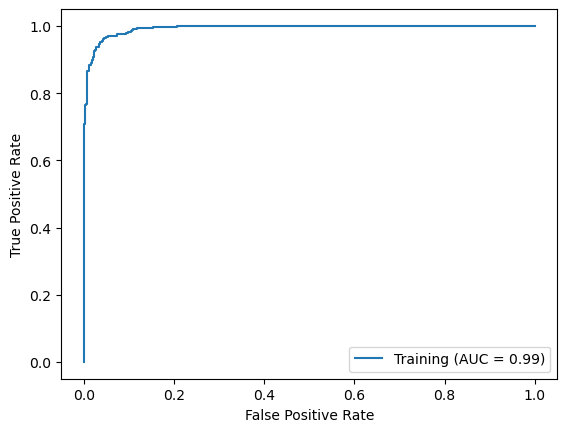

Testing Accuracy: 0.6834170854271356
Testing MCC Score: 0.36071562269392843
Testing F1 Score: 0.6794999616535009
Testing AUC VALUE: 0.7429906542056074
Testing kappa Score: 0.3598018689679825
Testing Precision: 0.6929824561403509
Testing Recall: 0.7383177570093458
Testing Sensitivity: 0.7383177570093458
Testing Specificity: 0.6195652173913043
Testing CCR: 0.6834170854271356
Testing PPV: 0.6929824561403509


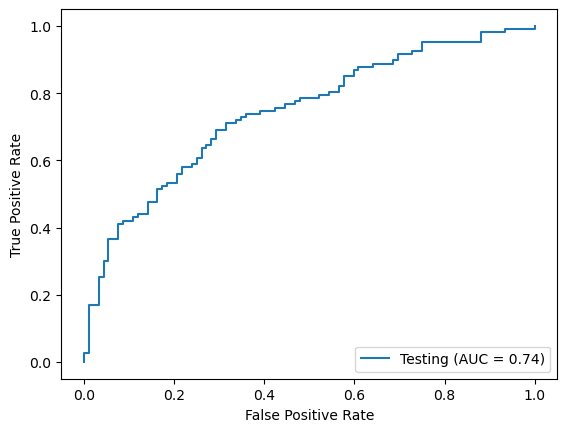

In [27]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [28]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
4,0.763819,0.527938,0.763795,0.824237,0.527698,0.750000,0.773196,0.773196,0.754902,0.763819,0.750000
14,0.753769,0.513803,0.753669,0.809422,0.509433,0.810526,0.712963,0.712963,0.802198,0.753769,0.810526
11,0.738693,0.479660,0.738634,0.806484,0.478112,0.773196,0.714286,0.714286,0.765957,0.738693,0.773196
17,0.733668,0.467158,0.733561,0.764599,0.467135,0.731959,0.724490,0.724490,0.742574,0.733668,0.731959
10,0.728643,0.458670,0.727480,0.782146,0.456339,0.782178,0.711712,0.711712,0.750000,0.728643,0.782178
3,0.723618,0.445549,0.722609,0.764423,0.445345,0.717391,0.694737,0.694737,0.750000,0.723618,0.717391
7,0.718593,0.437753,0.718586,0.775207,0.437399,0.731959,0.702970,0.702970,0.734694,0.718593,0.731959
18,0.718593,0.437639,0.718529,0.777273,0.437285,0.708738,0.737374,0.737374,0.700000,0.718593,0.708738
13,0.718593,0.437412,0.718415,0.795243,0.437058,0.696970,0.726316,0.726316,0.711538,0.718593,0.696970
6,0.713568,0.431280,0.713452,0.778722,0.428651,0.750000,0.669903,0.669903,0.760417,0.713568,0.750000


In [29]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,True,0.0,None,gini,NaN,None,None,None,0.0,3,25,0.0,67,None,False,None,0,False
1,True,0.0,None,gini,70.0,0.5,None,None,0.0,10,25,0.0,12,None,False,None,0,False
2,False,0.0,None,gini,70.0,log2,None,None,0.0,10,13,0.0,100,None,False,None,0,False
3,True,0.0,None,gini,110.0,log2,None,None,0.0,9,17,0.0,100,None,False,None,0,False
4,True,0.0,None,gini,40.0,0.5,None,None,0.0,9,17,0.0,23,None,False,None,0,False
5,True,0.0,None,gini,30.0,sqrt,None,None,0.0,9,7,0.0,78,None,False,None,0,False
6,False,0.0,None,gini,100.0,log2,None,None,0.0,3,26,0.0,100,None,False,None,0,False
7,True,0.0,None,gini,NaN,0.5,None,None,0.0,15,11,0.0,89,None,False,None,0,False
8,True,0.0,None,gini,40.0,None,None,None,0.0,12,20,0.0,100,None,False,None,0,False
9,True,0.0,None,gini,90.0,log2,None,None,0.0,15,8,0.0,12,None,False,None,0,False


In [30]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[4])

48

In [31]:
#Save the feature names
pd.DataFrame(features[4]).to_csv('AID_1205_features.csv',index=False)

In [32]:
#save the best parameters of the chosen model
with open('AID_1205_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[4].keys())
    w.writeheader()
    w.writerow(Best_params[4])

In [33]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

"\n#Randomly split the data into testing and validation for each fold\ndef Test_valid_split(Set3,frac,seed):\n    Fraction=frac\n    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))\n    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]\n    Valid=Set3.T[Valid_index].T\n    print('Test set size:',len(Test),'\nValid set size:',len(Valid))\n    return Test,Valid\n"

In [34]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [35]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1205_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['B2_60', 'B2_98', 'C1_41', 'C1_57', 'C1_73', 'C1_76', 'C1_95', 'C1_102', 'C1_121', 'D1_64', 'D1_97', 'D2_104', 'D5_6', 'D5_102', 'D5_105', 'E1_9', 'E1_90', 'E1_96', 'E1_103', 'E2_9', 'E2_94', 'E4_5', 'E4_6', 'E4_15', 'E4_17', 'E4_18', 'E4_22', 'E4_23', 'E4_29', 'E4_37', 'E4_48', 'E4_70', 'E4_74', 'E4_79', 'E4_85', 'E4_90', 'E4_95', 'E4_102', 'E4_106', 'E4_111', 'E4_112', 'E4_116', 'E4_117', 'E4_118', 'E4_120', 'E4_122', 'E4_125', 'E5_29']


In [36]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [37]:
y_train_prob

array([[0.56535124, 0.43464876],
       [0.67961126, 0.32038874],
       [0.67282806, 0.32717194],
       ...,
       [0.95114204, 0.04885796],
       [0.94692884, 0.05307116],
       [0.88564013, 0.11435987]])

2024-11-04 22:33:56,179:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:33:56,180:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:33:56,181:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 40.0, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 9, 'min_samples_split': 17, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 23, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


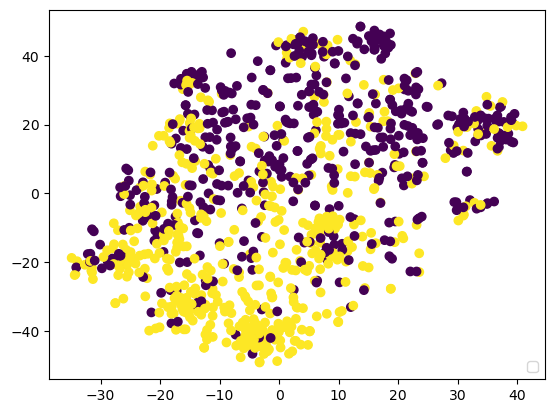

0
1    513
0    495
Name: count, dtype: int64
Training Accuracy: 0.9117063492063492
Training MCC Score: 0.8234796244608665
Training F1 Score: 0.911695833329232
Training AUC VALUE: 0.9721857955776084
Training kappa Score: 0.8234001842534193
Training Precision: 0.9189723320158103
Training Recall: 0.9064327485380117
Training Sensitivity: 0.9064327485380117
Training Specificity: 0.9171717171717172
Training CCR: 0.9117063492063492
Training PPV: 0.9189723320158103


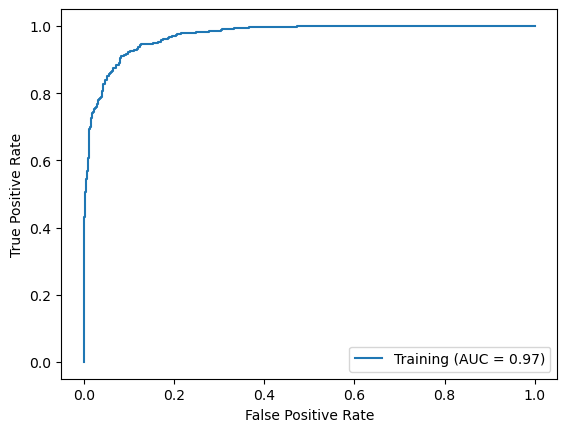

Testing Accuracy: 0.7567567567567568
Testing MCC Score: 0.5134784291601049
Testing F1 Score: 0.7566777624421531
Testing AUC VALUE: 0.792722547108512
Testing kappa Score: 0.5133950316609839
Testing Precision: 0.7678571428571429
Testing Recall: 0.7543859649122807
Testing Sensitivity: 0.7543859649122807
Testing Specificity: 0.7592592592592593
Testing CCR: 0.7567567567567568
Testing PPV: 0.7678571428571429


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


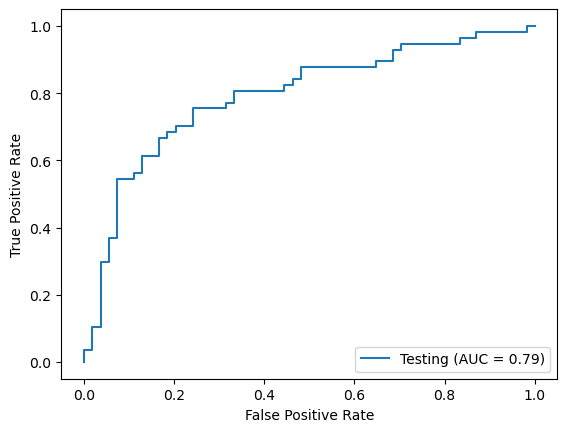

2024-11-04 22:33:58,038:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:33:58,038:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:33:58,039:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


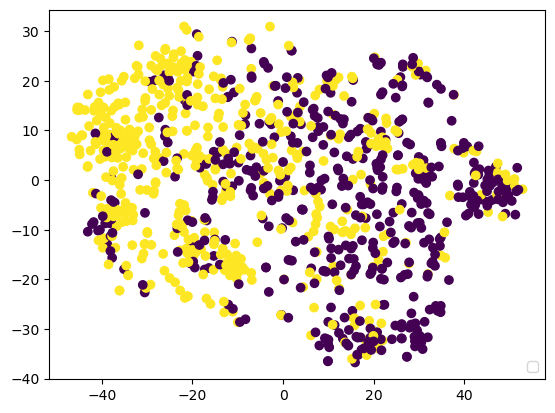

0
1    513
0    495
Name: count, dtype: int64
Training Accuracy: 0.8878968253968254
Training MCC Score: 0.7757597266204649
Training F1 Score: 0.8878719954638481
Training AUC VALUE: 0.963622580581645
Training kappa Score: 0.775745977744702
Training Precision: 0.8921568627450981
Training Recall: 0.8869395711500975
Training Sensitivity: 0.8869395711500975
Training Specificity: 0.8888888888888888
Training CCR: 0.8878968253968254
Training PPV: 0.8921568627450981


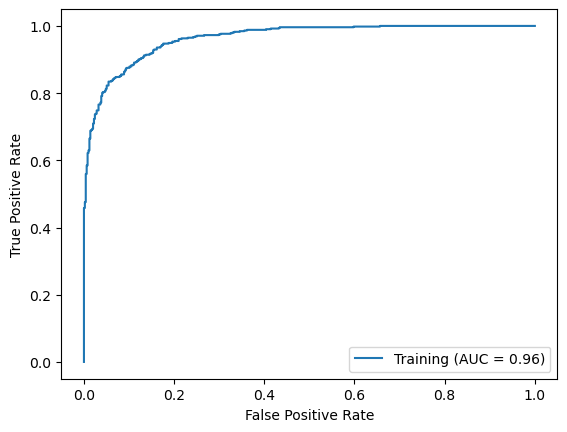

Testing Accuracy: 0.6576576576576577
Testing MCC Score: 0.3148148148148148
Testing F1 Score: 0.6574074074074074
Testing AUC VALUE: 0.6858349577647822
Testing kappa Score: 0.31481481481481477
Testing Precision: 0.6666666666666666
Testing Recall: 0.6666666666666666
Testing Sensitivity: 0.6666666666666666
Testing Specificity: 0.6481481481481481
Testing CCR: 0.6576576576576577
Testing PPV: 0.6666666666666666


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


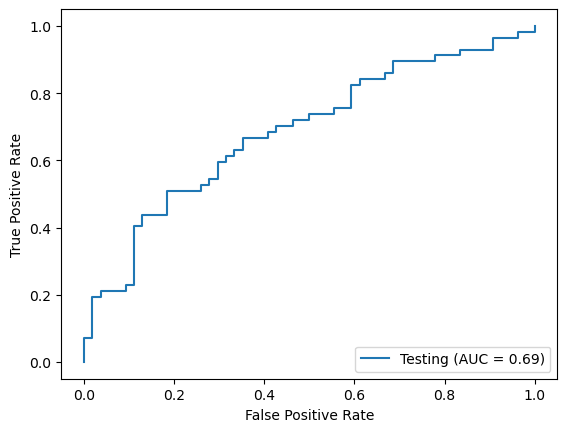

2024-11-04 22:33:59,909:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:33:59,909:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:33:59,910:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


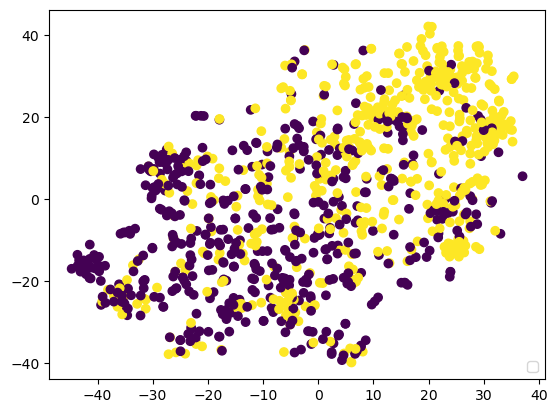

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.8949454905847374
Training MCC Score: 0.791440255109014
Training F1 Score: 0.8949280487900722
Training AUC VALUE: 0.9696617776520153
Training kappa Score: 0.7900417348833739
Training Precision: 0.9213250517598344
Training Recall: 0.8674463937621832
Training Sensitivity: 0.8674463937621832
Training Specificity: 0.9233870967741935
Training CCR: 0.8949454905847374
Training PPV: 0.9213250517598344


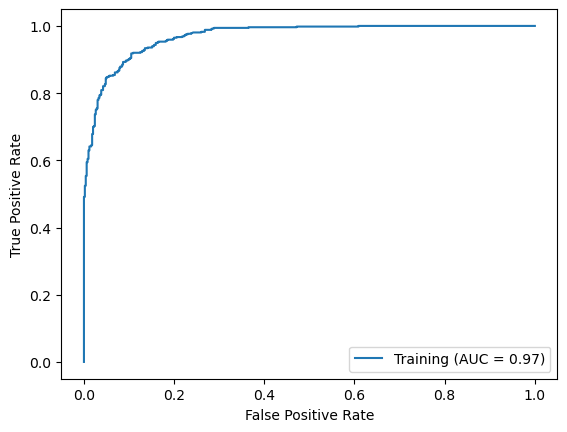

Testing Accuracy: 0.6272727272727273
Testing MCC Score: 0.2614714267129196
Testing F1 Score: 0.6265010351966874
Testing AUC VALUE: 0.7173121482952665
Testing kappa Score: 0.25797959855215524
Testing Precision: 0.6666666666666666
Testing Recall: 0.5614035087719298
Testing Sensitivity: 0.5614035087719298
Testing Specificity: 0.6981132075471698
Testing CCR: 0.6272727272727273
Testing PPV: 0.6666666666666666


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


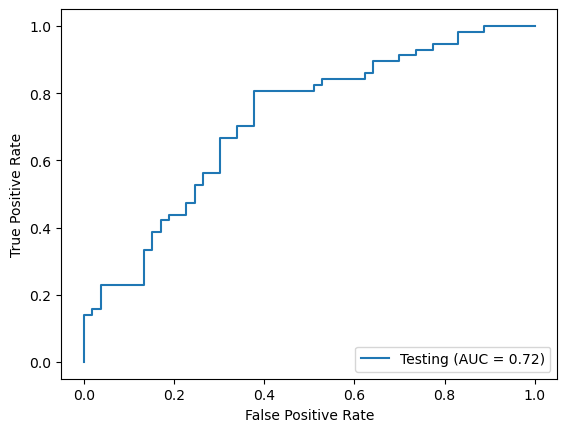

2024-11-04 22:34:01,767:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:01,768:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:01,768:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


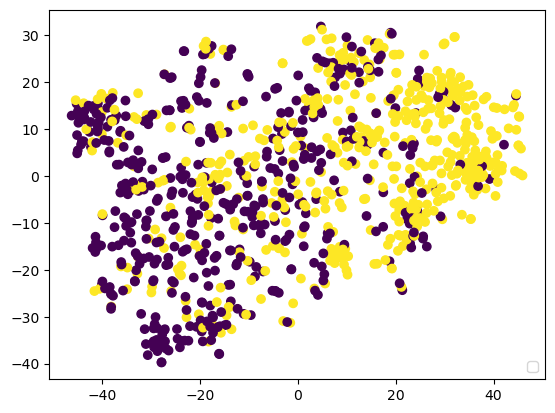

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.8939544103072349
Training MCC Score: 0.787922733569519
Training F1 Score: 0.8939394088239252
Training AUC VALUE: 0.9638374048921586
Training kappa Score: 0.7878840271051375
Training Precision: 0.8996062992125984
Training Recall: 0.8908382066276803
Training Sensitivity: 0.8908382066276803
Training Specificity: 0.8971774193548387
Training CCR: 0.8939544103072349
Training PPV: 0.8996062992125984


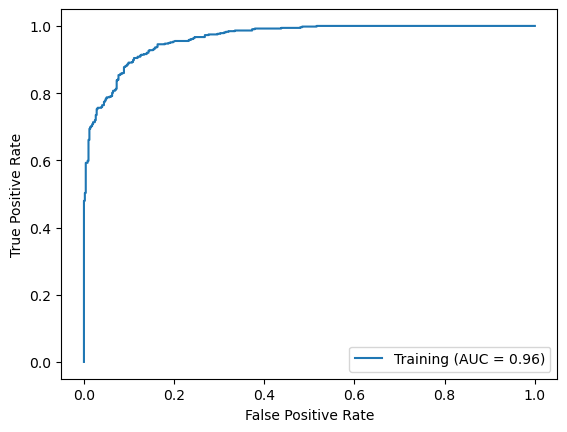

Testing Accuracy: 0.6909090909090909
Testing MCC Score: 0.3883582504155166
Testing F1 Score: 0.69049983449189
Testing AUC VALUE: 0.7322078781860311
Testing kappa Score: 0.38426078366809346
Testing Precision: 0.7346938775510204
Testing Recall: 0.631578947368421
Testing Sensitivity: 0.631578947368421
Testing Specificity: 0.7547169811320755
Testing CCR: 0.6909090909090909
Testing PPV: 0.7346938775510204


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


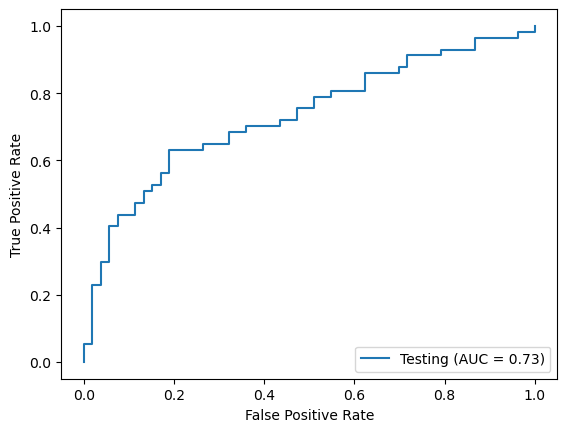

2024-11-04 22:34:03,647:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:03,648:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:03,649:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #5


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


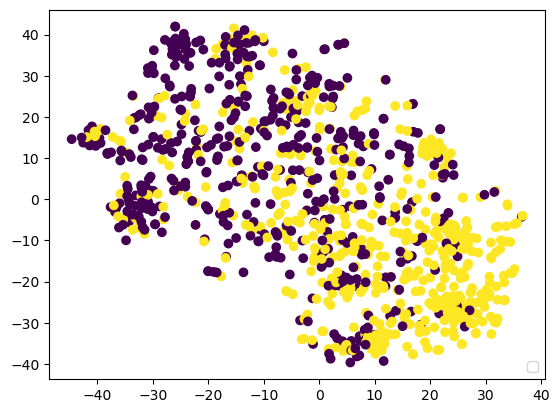

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.88800792864222
Training MCC Score: 0.7765201534301704
Training F1 Score: 0.8880079286422199
Training AUC VALUE: 0.9662131358863106
Training kappa Score: 0.7760794210355764
Training Precision: 0.9032258064516129
Training Recall: 0.8732943469785575
Training Sensitivity: 0.8732943469785575
Training Specificity: 0.9032258064516129
Training CCR: 0.88800792864222
Training PPV: 0.9032258064516129


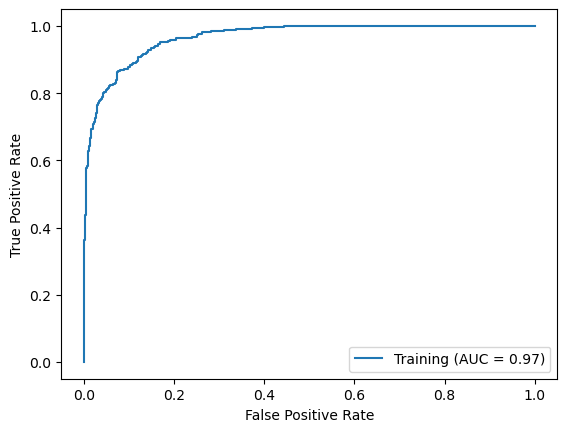

Testing Accuracy: 0.7181818181818181
Testing MCC Score: 0.4353157033873693
Testing F1 Score: 0.7175983436853002
Testing AUC VALUE: 0.8017212843429328
Testing kappa Score: 0.4352434580987081
Testing Precision: 0.7241379310344828
Testing Recall: 0.7368421052631579
Testing Sensitivity: 0.7368421052631579
Testing Specificity: 0.6981132075471698
Testing CCR: 0.7181818181818181
Testing PPV: 0.7241379310344828


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


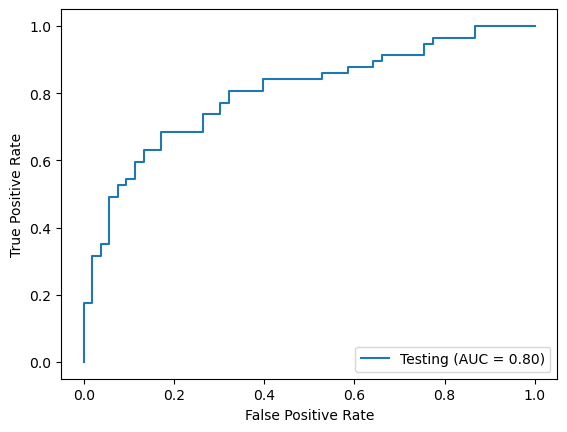

2024-11-04 22:34:05,642:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:05,643:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:05,644:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


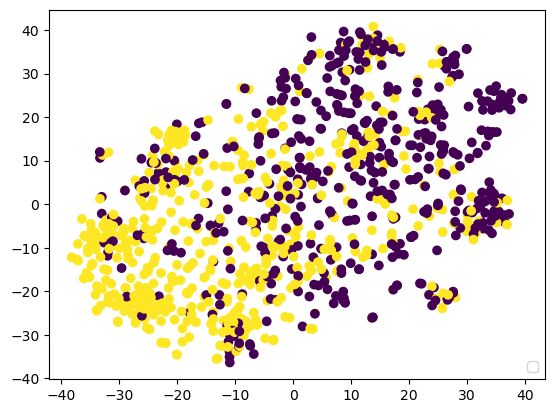

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.8919722497522299
Training MCC Score: 0.7840728768665517
Training F1 Score: 0.8919654583371397
Training AUC VALUE: 0.967614208011067
Training kappa Score: 0.7839481071566785
Training Precision: 0.9007936507936508
Training Recall: 0.884990253411306
Training Sensitivity: 0.884990253411306
Training Specificity: 0.8991935483870968
Training CCR: 0.8919722497522299
Training PPV: 0.9007936507936508


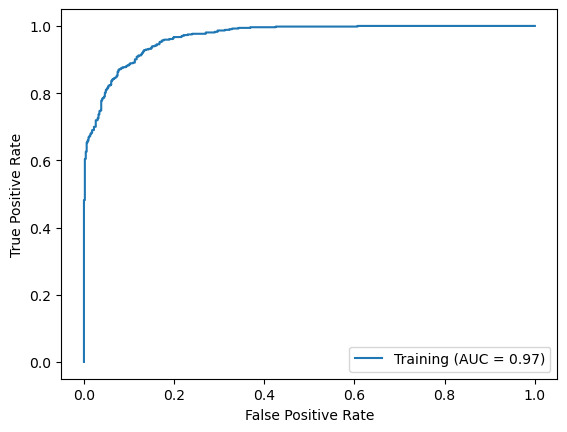

Testing Accuracy: 0.7272727272727273
Testing MCC Score: 0.4587073759715455
Testing F1 Score: 0.7271825396825398
Testing AUC VALUE: 0.7752399867593511
Testing kappa Score: 0.4559841740850643
Testing Precision: 0.7647058823529411
Testing Recall: 0.6842105263157895
Testing Sensitivity: 0.6842105263157895
Testing Specificity: 0.7735849056603774
Testing CCR: 0.7272727272727273
Testing PPV: 0.7647058823529411


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


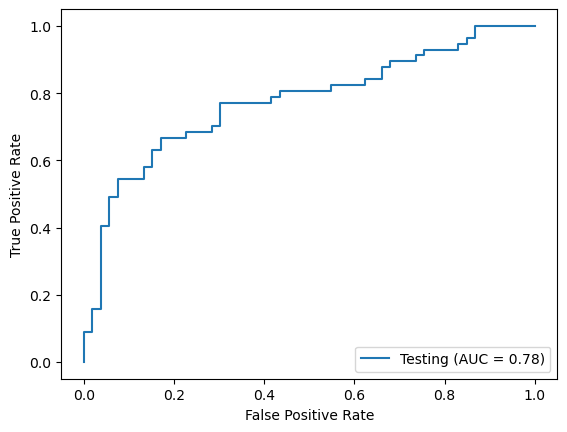

2024-11-04 22:34:07,507:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:07,507:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:07,508:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


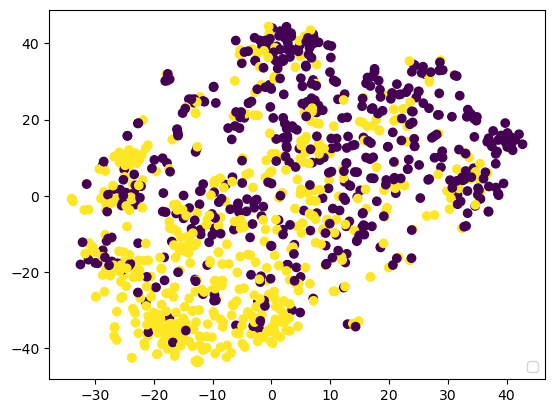

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.9137760158572844
Training MCC Score: 0.8279553426865409
Training F1 Score: 0.9137756770853285
Training AUC VALUE: 0.9694809941520468
Training kappa Score: 0.8275894577443627
Training Precision: 0.927710843373494
Training Recall: 0.9005847953216374
Training Sensitivity: 0.9005847953216374
Training Specificity: 0.9274193548387096
Training CCR: 0.9137760158572844
Training PPV: 0.927710843373494


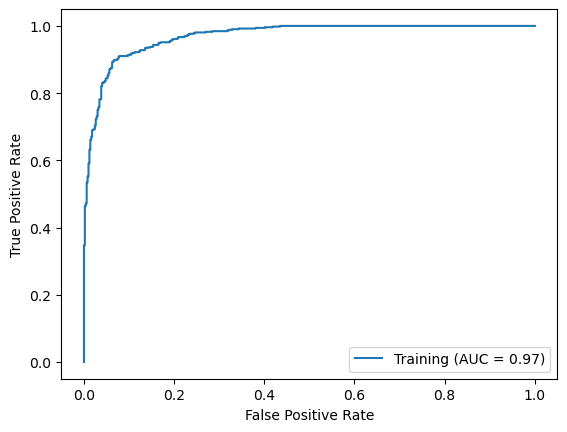

Testing Accuracy: 0.7454545454545455
Testing MCC Score: 0.489884883810537
Testing F1 Score: 0.7446949602122017
Testing AUC VALUE: 0.8000662032439589
Testing kappa Score: 0.4895591647331786
Testing Precision: 0.7457627118644068
Testing Recall: 0.7719298245614035
Testing Sensitivity: 0.7719298245614035
Testing Specificity: 0.7169811320754716
Testing CCR: 0.7454545454545455
Testing PPV: 0.7457627118644068


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


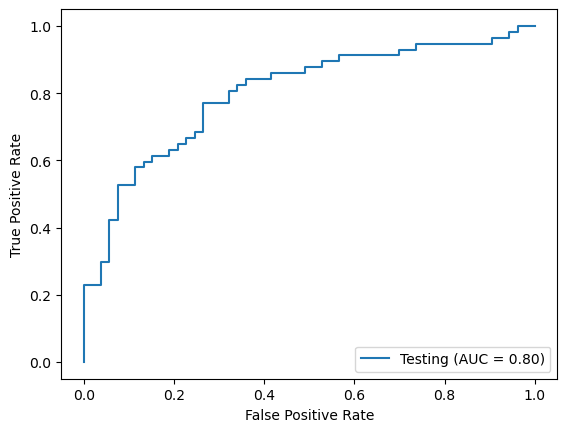

2024-11-04 22:34:09,511:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:09,512:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:09,513:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


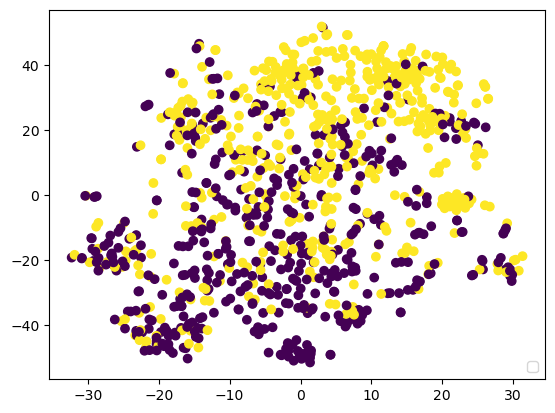

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.9147670961347869
Training MCC Score: 0.8297057249284603
Training F1 Score: 0.914762993697644
Training AUC VALUE: 0.9708879613909325
Training kappa Score: 0.8295427311979193
Training Precision: 0.9244532803180915
Training Recall: 0.9064327485380117
Training Sensitivity: 0.9064327485380117
Training Specificity: 0.9233870967741935
Training CCR: 0.9147670961347869
Training PPV: 0.9244532803180915


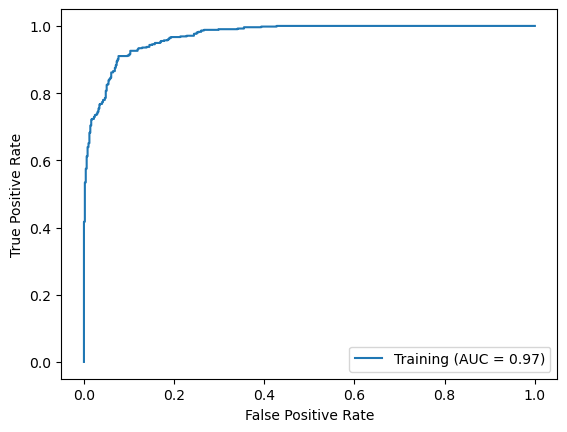

Testing Accuracy: 0.7090909090909091
Testing MCC Score: 0.4200595829195631
Testing F1 Score: 0.709090909090909
Testing AUC VALUE: 0.7752399867593511
Testing kappa Score: 0.41895014856388246
Testing Precision: 0.7358490566037735
Testing Recall: 0.6842105263157895
Testing Sensitivity: 0.6842105263157895
Testing Specificity: 0.7358490566037735
Testing CCR: 0.7090909090909091
Testing PPV: 0.7358490566037735


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


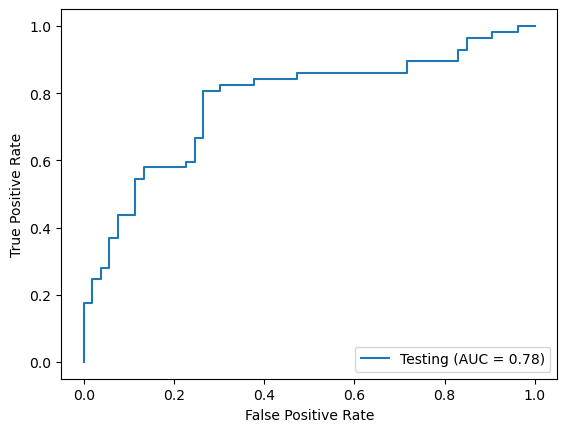

2024-11-04 22:34:11,405:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:11,406:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:11,406:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


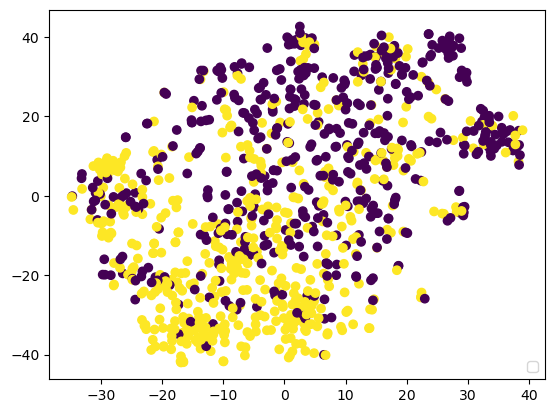

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.8929633300297324
Training MCC Score: 0.7860918092446161
Training F1 Score: 0.8929581781319251
Training AUC VALUE: 0.9670129063698673
Training kappa Score: 0.7859373833648289
Training Precision: 0.9025844930417495
Training Recall: 0.884990253411306
Training Sensitivity: 0.884990253411306
Training Specificity: 0.9012096774193549
Training CCR: 0.8929633300297324
Training PPV: 0.9025844930417495


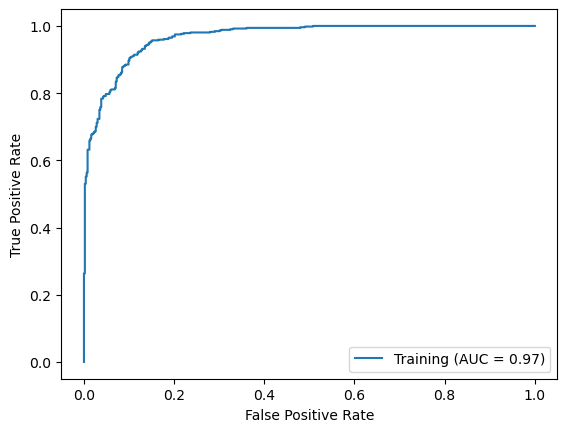

Testing Accuracy: 0.7181818181818181
Testing MCC Score: 0.4373863235066633
Testing F1 Score: 0.718158525497975
Testing AUC VALUE: 0.8027143330023172
Testing kappa Score: 0.43673604228609186
Testing Precision: 0.7407407407407407
Testing Recall: 0.7017543859649122
Testing Sensitivity: 0.7017543859649122
Testing Specificity: 0.7358490566037735
Testing CCR: 0.7181818181818181
Testing PPV: 0.7407407407407407


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


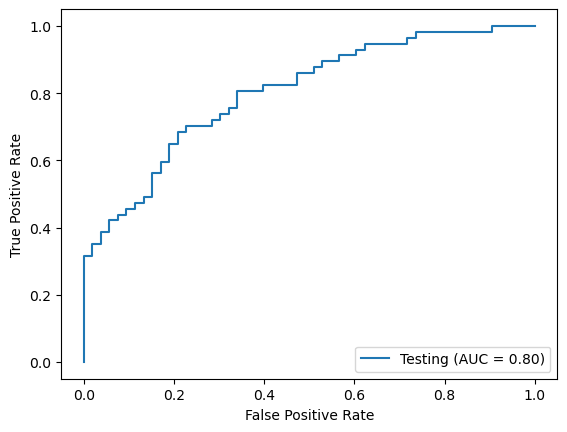

2024-11-04 22:34:13,277:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:34:13,278:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:34:13,278:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_48884\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


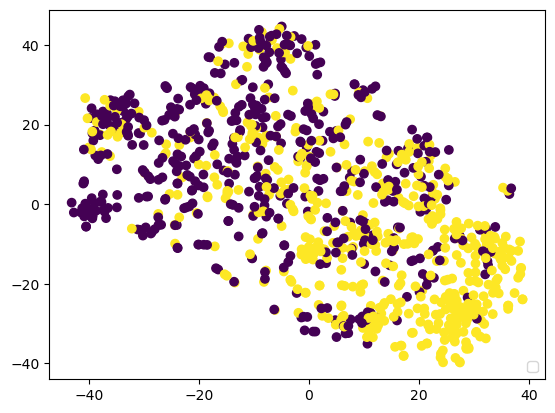

0
1    513
0    496
Name: count, dtype: int64
Training Accuracy: 0.88800792864222
Training MCC Score: 0.7761431051709173
Training F1 Score: 0.888000888000888
Training AUC VALUE: 0.9662937024460793
Training kappa Score: 0.7760195973275658
Training Precision: 0.8968253968253969
Training Recall: 0.8810916179337231
Training Sensitivity: 0.8810916179337231
Training Specificity: 0.8951612903225806
Training CCR: 0.88800792864222
Training PPV: 0.8968253968253969


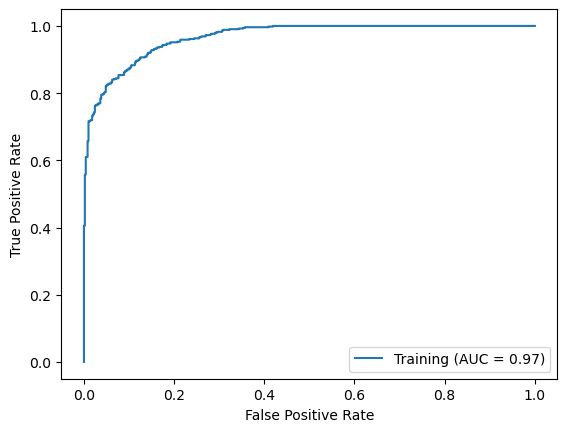

Testing Accuracy: 0.7272727272727273
Testing MCC Score: 0.4535838006138382
Testing F1 Score: 0.7258225324027916
Testing AUC VALUE: 0.7818603111552467
Testing kappa Score: 0.45237305011616324
Testing Precision: 0.7213114754098361
Testing Recall: 0.7719298245614035
Testing Sensitivity: 0.7719298245614035
Testing Specificity: 0.6792452830188679
Testing CCR: 0.7272727272727273
Testing PPV: 0.7213114754098361


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


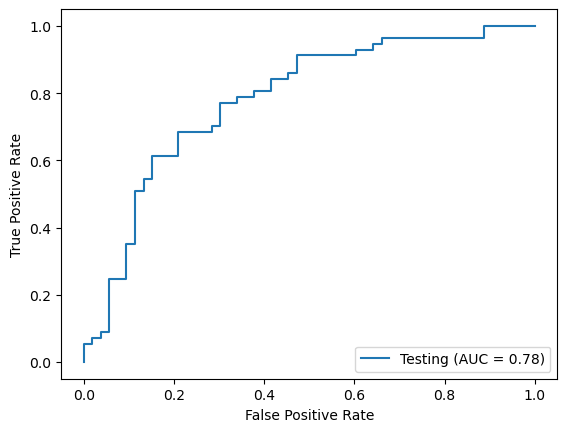

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [38]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[4].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [45]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.756757,0.513478,0.756678,0.792723,0.513395,0.767857,0.754386,0.754386,0.759259,0.756757,0.767857
6,0.745455,0.489885,0.744695,0.800066,0.489559,0.745763,0.771930,0.771930,0.716981,0.745455,0.745763
5,0.727273,0.458707,0.727183,0.775240,0.455984,0.764706,0.684211,0.684211,0.773585,0.727273,0.764706
9,0.727273,0.453584,0.725823,0.781860,0.452373,0.721311,0.771930,0.771930,0.679245,0.727273,0.721311
8,0.718182,0.437386,0.718159,0.802714,0.436736,0.740741,0.701754,0.701754,0.735849,0.718182,0.740741
4,0.718182,0.435316,0.717598,0.801721,0.435243,0.724138,0.736842,0.736842,0.698113,0.718182,0.724138
7,0.709091,0.420060,0.709091,0.775240,0.418950,0.735849,0.684211,0.684211,0.735849,0.709091,0.735849
3,0.690909,0.388358,0.690500,0.732208,0.384261,0.734694,0.631579,0.631579,0.754717,0.690909,0.734694
1,0.657658,0.314815,0.657407,0.685835,0.314815,0.666667,0.666667,0.666667,0.648148,0.657658,0.666667
2,0.627273,0.261471,0.626501,0.717312,0.257980,0.666667,0.561404,0.561404,0.698113,0.627273,0.666667


<Axes: >

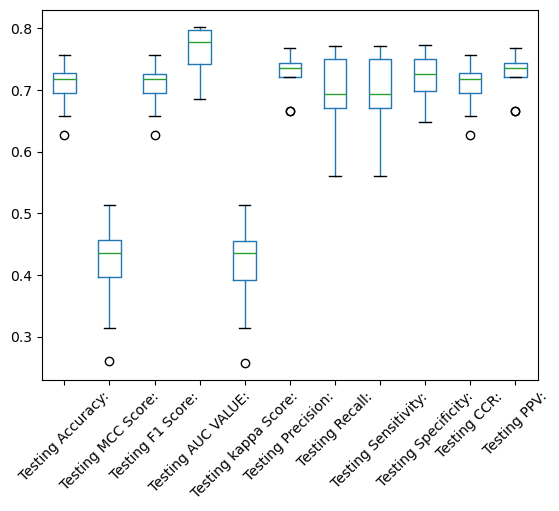

In [40]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [41]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.756757,0.513478,0.756678,0.792723,0.513395,0.767857,0.754386,0.754386,0.759259,0.756757,0.767857
1,0.657658,0.314815,0.657407,0.685835,0.314815,0.666667,0.666667,0.666667,0.648148,0.657658,0.666667
2,0.627273,0.261471,0.626501,0.717312,0.257980,0.666667,0.561404,0.561404,0.698113,0.627273,0.666667
3,0.690909,0.388358,0.690500,0.732208,0.384261,0.734694,0.631579,0.631579,0.754717,0.690909,0.734694
4,0.718182,0.435316,0.717598,0.801721,0.435243,0.724138,0.736842,0.736842,0.698113,0.718182,0.724138
5,0.727273,0.458707,0.727183,0.775240,0.455984,0.764706,0.684211,0.684211,0.773585,0.727273,0.764706
6,0.745455,0.489885,0.744695,0.800066,0.489559,0.745763,0.771930,0.771930,0.716981,0.745455,0.745763
7,0.709091,0.420060,0.709091,0.775240,0.418950,0.735849,0.684211,0.684211,0.735849,0.709091,0.735849
8,0.718182,0.437386,0.718159,0.802714,0.436736,0.740741,0.701754,0.701754,0.735849,0.718182,0.740741
9,0.727273,0.453584,0.725823,0.781860,0.452373,0.721311,0.771930,0.771930,0.679245,0.727273,0.721311


In [42]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,-0.098010,0.002390,-0.101412,0.077286,-0.074652,0.101418,0.101440,-0.097685,0.094374,-0.096629,...,0.052603,0.056732,-0.096194,0.120066,-0.113271,-0.020535,-0.011765,0.029151,0.084404,-0.116883
1,-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,-0.019364,...,0.014489,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311
2,-0.099847,0.032736,-0.100179,0.091849,-0.003701,0.100570,0.100114,-0.094547,0.039664,-0.081377,...,-0.068134,0.057959,-0.101668,0.020425,0.057304,0.054510,0.106825,0.008758,0.045399,0.129491
3,0.099021,0.075273,-0.096130,-0.100559,-0.065504,0.099196,0.100980,-0.078878,0.096602,0.100281,...,-0.131319,-0.072649,-0.040036,0.002427,0.068754,0.133684,0.125872,0.021306,0.046899,0.082696
4,0.076265,-0.090504,0.088984,0.099890,0.099742,0.099830,0.096466,-0.099833,0.099675,-0.009590,...,-0.165453,0.050826,0.003350,-0.110016,-0.045905,0.121653,0.062609,0.093750,-0.077514,-0.002801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,-0.093829,-0.093857,0.093865,-0.080484,0.093865,0.080181,-0.093865,-0.093865,-0.092671,0.093865,...,0.104014,-0.039911,0.013868,0.078227,0.042474,-0.062536,-0.012488,0.001919,0.140213,-0.061796
1098,-0.097989,-0.054378,-0.096215,0.073114,-0.087902,0.097986,0.097998,-0.097529,0.028526,-0.086145,...,-0.049566,0.039496,-0.066307,0.048998,-0.005742,-0.094280,-0.121242,0.153560,0.068190,0.045642
1099,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,-0.014191,...,-0.142667,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199
1100,0.094904,0.095126,0.095131,-0.094880,0.095143,0.089252,0.094964,0.095148,0.062624,0.095051,...,-0.110147,-0.104988,0.055509,0.112147,0.034040,-0.109844,0.092205,-0.108522,-0.065427,0.010976


In [43]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,B2_60,B2_98,C1_41,C1_57,C1_73,C1_76,C1_95,C1_102,C1_121,D1_64,...,E4_106,E4_111,E4_112,E4_116,E4_117,E4_118,E4_120,E4_122,E4_125,E5_29
0,-0.002403,0.109946,0.021340,-0.060567,-0.042838,-0.000587,0.100157,-0.120566,-0.076859,-0.120891,...,0.086160,0.062742,0.098632,0.033419,-0.043554,0.015617,-0.044759,-0.125542,-0.104272,-0.131471
1,0.146781,-0.070236,-0.022308,-0.106556,-0.060159,0.041679,0.087306,-0.116226,-0.007962,-0.013367,...,0.101986,-0.094009,0.110870,-0.089854,-0.109663,0.015329,-0.100924,-0.067218,0.111537,0.040300
2,0.014090,0.133556,0.068226,-0.018799,-0.052880,0.032538,0.007937,-0.087241,-0.080156,-0.117161,...,-0.108226,-0.040226,0.083073,-0.087519,0.099867,0.127856,-0.074855,0.117292,-0.107197,-0.095376
3,0.123519,0.078404,-0.066408,-0.115978,-0.109472,-0.015084,0.116893,0.065195,-0.118555,0.097247,...,0.097444,-0.104655,-0.107135,0.088310,0.077295,0.103377,0.106580,-0.093660,-0.082448,-0.109766
4,0.114765,-0.068192,0.072123,0.111200,-0.112296,0.105424,0.053509,-0.092608,-0.017264,0.094535,...,-0.136865,0.085834,0.115379,-0.118384,0.035427,0.024927,0.008040,0.133462,-0.020418,-0.124588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,-0.002080,0.135956,-0.109785,-0.097797,-0.121607,0.051146,0.025749,-0.115685,0.067296,-0.111338,...,-0.114698,-0.005645,-0.097545,-0.102768,0.002007,0.114606,0.103442,0.114338,-0.073336,-0.098707
1098,0.079961,-0.048975,-0.109343,-0.088878,0.012290,-0.044716,0.111750,0.101252,-0.097433,0.053382,...,0.052008,0.077878,0.021082,-0.131240,-0.131132,0.131182,0.094091,-0.042211,0.062183,0.060976
1099,-0.012102,0.175648,-0.112086,-0.096931,-0.149915,0.105963,0.133409,-0.116235,-0.054996,-0.147737,...,-0.032249,0.110956,0.113750,-0.065195,0.089054,0.111636,0.059335,0.065277,-0.098176,-0.068765
1100,-0.125034,0.024539,-0.075226,-0.100907,-0.101814,-0.066712,0.101679,-0.093949,-0.100669,0.097859,...,-0.091145,-0.095360,-0.094856,-0.093868,0.094804,0.095276,-0.071868,0.093824,-0.094006,-0.093842


In [44]:
Y = Data['status']

In [46]:
#Fitting the model on whole data
fitted = models_1[0].fit(TRAIN,Y)
fitted

RandomForestClassifier(max_depth=40.0, max_features=0.5, min_samples_leaf=9,
                       min_samples_split=17, n_estimators=23)

In [47]:
#Save the final model
joblib.dump(fitted, 'AID_1205_RF.pkl')

['AID_1205_RF.pkl']

In [48]:
import joblib
import pandas as pd

class model_AID_1205:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1205_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1205_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1205(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1205(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1205_0'] = None
    Feature_data['AID_1205_1'] = None
    Feature_data['AID_1205_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1205_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1205_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1205_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
